<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/hau/Marketing_Campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Giới thiệu

# Chuẩn bị môi trường

In [28]:
%pip uninstall numpy
%pip install numpy==1.26.4
%pip uninstall sweetviz
%pip install sweetviz==2.2.1
%pip install autoviz
%pip install autoviz

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/lib/python3.12/dist-packages/numpy-1.26.4.dist-info/*
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libopenblas64_p-r0-0cf96a72.3.23.dev.so
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.12/dist-packages/numpy/*
Proceed (Y/n)? y
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9",

Found existing installation: sweetviz 2.2.1
Uninstalling sweetviz-2.2.1:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/sweetviz-2.2.1.dist-info/*
    /usr/local/lib/python3.12/dist-packages/sweetviz/*
Proceed (Y/n)? y
  Successfully uninstalled sweetviz-2.2.1
  Using cached sweetviz-2.2.1-py3-none-any.whl.metadata (23 kB)
Using cached sweetviz-2.2.1-py3-none-any.whl (15.1 MB)


# Khai báo thư viện

In [53]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
from autoviz.AutoViz_Class import AutoViz_Class
import sweetviz as sv
from IPython.display import display, HTML
import matplotlib.pyplot as plt


# Load dataset

In [30]:



# Set the path to the file you'd like to load
file_path = "marketing_campaign.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "imakash3011/customer-personality-analysis",
  file_path,
  pandas_kwargs={
      # Use tab as a separator
      'sep': '\t',
      'engine': 'python'
  }
)
# df1 = df.copy()
print(df)

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
       ID    Year_Birth  Education  Marital_Status  Income   Kidhome  \
0      5524     1957     Graduation      Single     58138.0     0      
1      2174     1954     Graduation      Single     46344.0     1      
2      4141     1965     Graduation    Together     71613.0     0      
3      6182     1984     Graduation    Together     26646.0     1      
4      5324     1981            PhD     Married     58293.0     1      
...     ...         ...         ...            ...      ...      ...   
2235  10870     1967     Graduation     Married     61223.0     0      
2236   4001     1946            PhD    Together     64014.0     2      
2237   7270     1981     Graduation    Divorced     56981.0     0      
2238   8235     1956         Master    Together     69245.0     0      
2239   9405     1954            PhD     Married     52869.0     1      

      Teenhome Dt_Customer  Recency  MntWines  MntF

# Làm sạch dữ liệu

Để phân tích dataset Customer Personality Analysis nhằm phân loại khách hàng, em sẽ chọn các thuộc tính dựa trên mục tiêu phân tích hành vi và giá trị khách hàng:
1. Thông tin nhân khẩu (Demographics / People)

    Nhóm này giúp bạn hiểu đặc điểm cơ bản của khách hàng:

    Year_Birth → tính tuổi khách hàng.

    Education → phân loại theo trình độ học vấn.

    Marital_Status → tình trạng hôn nhân.

    Income → thu nhập hàng năm (rất quan trọng để phân nhóm theo khả năng chi tiêu).

    Kidhome → số trẻ em trong gia đình.

    Teenhome → số thanh thiếu niên trong gia đình.
2. Hành vi mua sắm sản phẩm (Products)

    Nhóm này phản ánh thói quen chi tiêu và sở thích sản phẩm:

    MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds → tổng số tiền chi cho từng loại sản phẩm.
3. Hành vi khuyến mãi / phản hồi chiến dịch (Promotion)

    Nhóm này phản ánh mức độ nhạy cảm với khuyến mãi:

    NumDealsPurchases → số lần mua hàng có giảm giá.

    AcceptedCmp1 - > AcceptedCmp5, Response → các cột nhị phân phản ánh khách hàng chấp nhận khuyến mãi.
  
4. Hành vi mua sắm kênh (Place)

    Nhóm này phản ánh cách khách hàng tương tác với công ty:

    NumWebPurchases, NumCatalogPurchases, NumStorePurchases → số lượng mua theo từng kênh.

    NumWebVisitsMonth → số lần truy cập website trong tháng gần nhất.
5. Hành vi gần đây / phản hồi khiếu nại (Recency / Complain)

    Recency → số ngày kể từ lần mua cuối cùng; quan trọng để xác định khách hàng còn tích cực hay không.

    Complain → khách hàng từng phàn nàn hay không (có thể ảnh hưởng đến phân nhóm dịch vụ).

In [39]:
cols_to_use = ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
 'Recency', 'Complain',
 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
 'NumDealsPurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response',
 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']


## Xử lí dữ liệu trùng lập

In [40]:
# xóa dữ liệu trùng lặp
marketing_data= df[cols_to_use].drop_duplicates()
marketing_data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Complain,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,1957,Graduation,Single,58138.0,0,0,58,0,635,88,546,172,88,88,3,0,0,0,0,0,1,8,10,4,7
1,1954,Graduation,Single,46344.0,1,1,38,0,11,1,6,2,1,6,2,0,0,0,0,0,0,1,1,2,5
2,1965,Graduation,Together,71613.0,0,0,26,0,426,49,127,111,21,42,1,0,0,0,0,0,0,8,2,10,4
3,1984,Graduation,Together,26646.0,1,0,26,0,11,4,20,10,3,5,2,0,0,0,0,0,0,2,0,4,6
4,1981,PhD,Married,58293.0,1,0,94,0,173,43,118,46,27,15,5,0,0,0,0,0,0,5,3,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2233,1977,Graduation,Together,666666.0,1,0,23,0,9,14,18,8,1,12,4,0,0,0,0,0,0,3,1,3,6
2235,1967,Graduation,Married,61223.0,0,1,46,0,709,43,182,42,118,247,2,0,0,0,0,0,0,9,3,4,5
2237,1981,Graduation,Divorced,56981.0,0,0,91,0,908,48,217,32,12,24,1,0,0,0,1,0,0,2,3,13,6
2238,1956,Master,Together,69245.0,0,1,8,0,428,30,214,80,30,61,2,0,0,0,0,0,0,6,5,10,3


## Thay thế dữ liệu và xử lí dữ liệu bị thiếu


### Thay thế dữ liệu

In [41]:
#Kiểm tra các giá trị trong cột Kidhome, Teenhome:
print('Kidhome:',marketing_data['Kidhome'].unique())
print('Teenhome:',marketing_data['Teenhome'].unique())

Kidhome: [0 1 2]
Teenhome: [0 1 2]


Nhận xét:


*   Vì Kidhome, Teenhome chứa số lượng trẻ em trong gia đình, nên ta tiến hành thay thế dữ liệu sang 'has no kid' với các giá trị bằng 0, 'has kid' với giá trị lớn hơn 0



In [42]:
# Thay thế dữ liệu của Kidhome, Teenhome bằng 'has teen','has no teen'
marketing_data['Teenhome_replaced'] =marketing_data['Teenhome'].replace([0,1,2],['has no teen','has teen','has teen'])

marketing_data['Kidhome_replaced'] =marketing_data['Kidhome'].replace([0,1,2],['has no kid','has kid', 'has kid'])

marketing_data

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Complain,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Teenhome_replaced,Kidhome_replaced
0,1957,Graduation,Single,58138.0,0,0,58,0,635,88,546,172,88,88,3,0,0,0,0,0,1,8,10,4,7,has no teen,has no kid
1,1954,Graduation,Single,46344.0,1,1,38,0,11,1,6,2,1,6,2,0,0,0,0,0,0,1,1,2,5,has teen,has kid
2,1965,Graduation,Together,71613.0,0,0,26,0,426,49,127,111,21,42,1,0,0,0,0,0,0,8,2,10,4,has no teen,has no kid
3,1984,Graduation,Together,26646.0,1,0,26,0,11,4,20,10,3,5,2,0,0,0,0,0,0,2,0,4,6,has no teen,has kid
4,1981,PhD,Married,58293.0,1,0,94,0,173,43,118,46,27,15,5,0,0,0,0,0,0,5,3,6,5,has no teen,has kid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2233,1977,Graduation,Together,666666.0,1,0,23,0,9,14,18,8,1,12,4,0,0,0,0,0,0,3,1,3,6,has no teen,has kid
2235,1967,Graduation,Married,61223.0,0,1,46,0,709,43,182,42,118,247,2,0,0,0,0,0,0,9,3,4,5,has teen,has no kid
2237,1981,Graduation,Divorced,56981.0,0,0,91,0,908,48,217,32,12,24,1,0,0,0,1,0,0,2,3,13,6,has no teen,has no kid
2238,1956,Master,Together,69245.0,0,1,8,0,428,30,214,80,30,61,2,0,0,0,0,0,0,6,5,10,3,has teen,has no kid


### Xử lí dữ liệu bị thiếu

In [46]:
# Kiểm tra số lượng dữ liệu bị thiếu
marketing_data.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Recency,0
Complain,0
MntWines,0
MntFruits,0


Nhận xét


*   Thay thế dữ liệu null trong cột 'Income' bằng giá trị median giúp tránh làm bóp méo phân bố tổng thể của cột Income và giữ cho các phép tính thống kê sau này (như tính trung bình nhóm, hồi quy) được chính xác hơn.









In [47]:
# Thay thế dữ liệu null bằng median(trung vị)
marketing_data['Income'].fillna(marketing_data['Income'].median(), inplace=True)
marketing_data.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
Complain,0
MntWines,0
MntFruits,0


# Phân tích khám phá dữ liệu

## SweetViz

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_don_bien.html was generated.



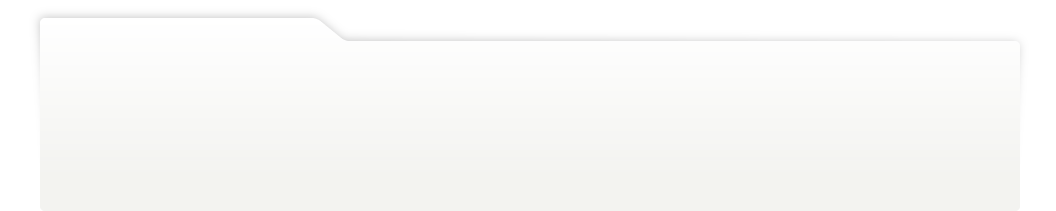
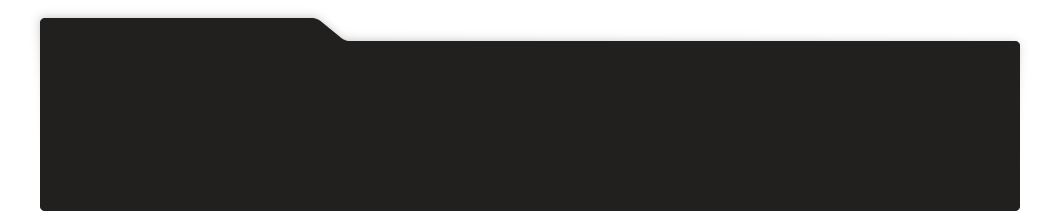
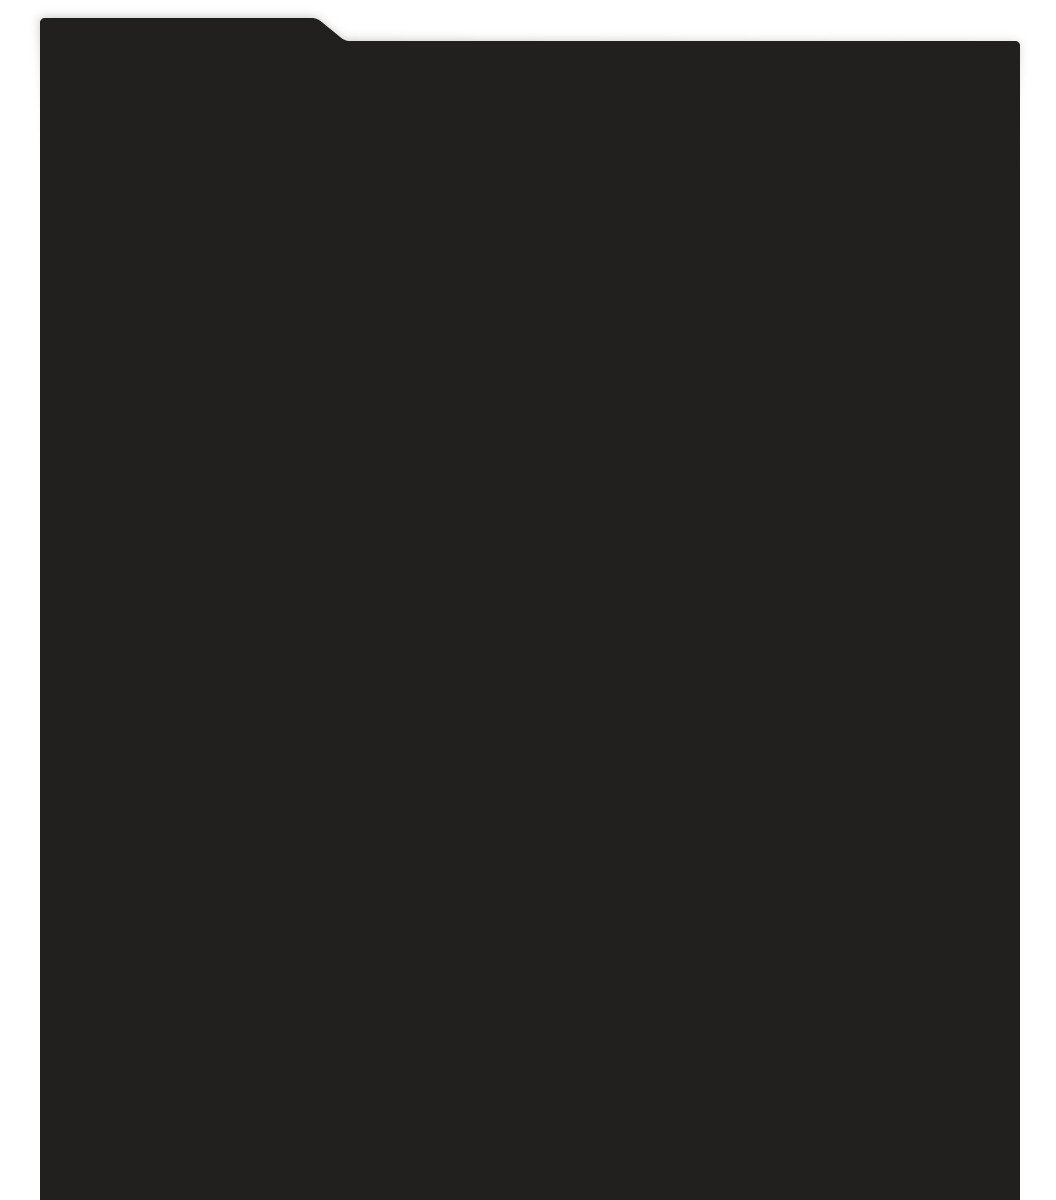
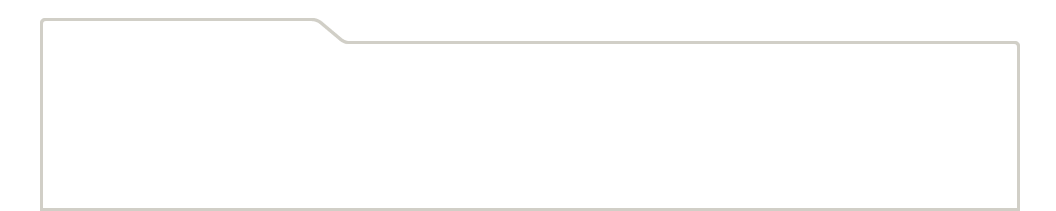
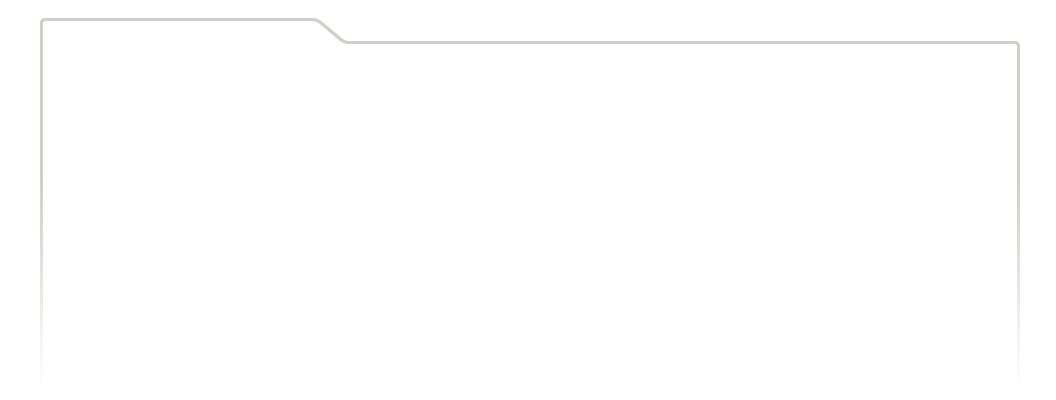
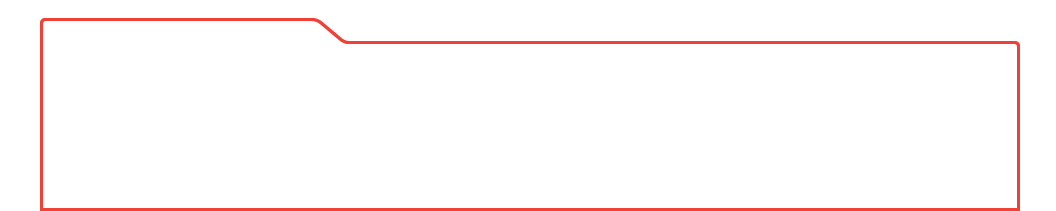
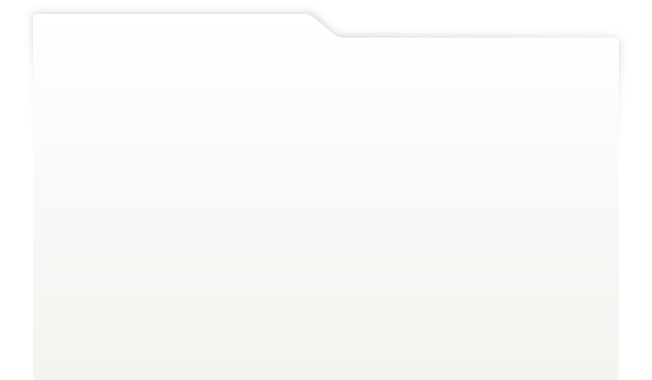
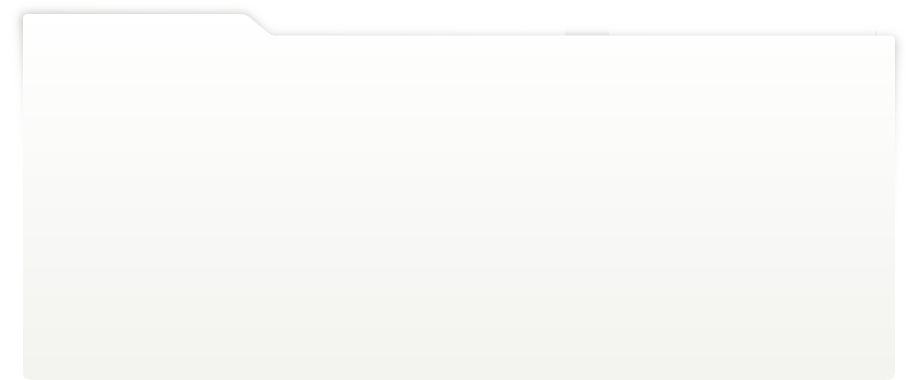
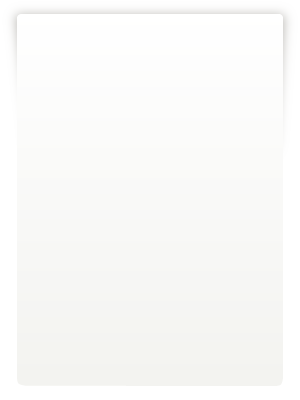
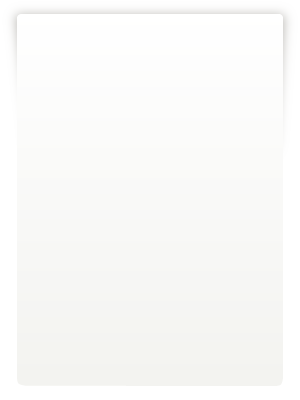
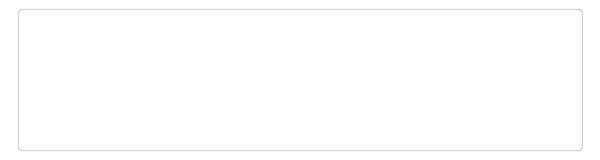
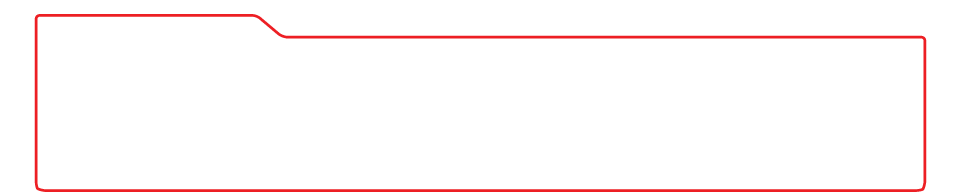
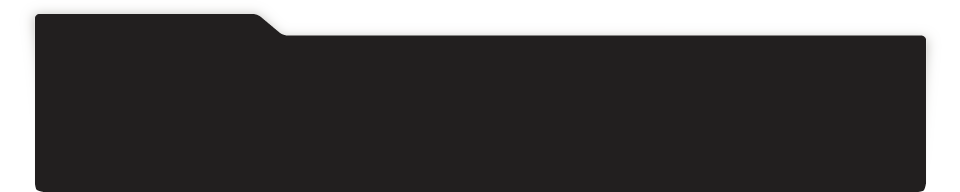
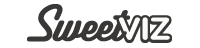
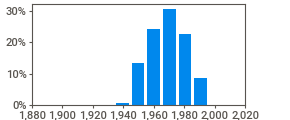
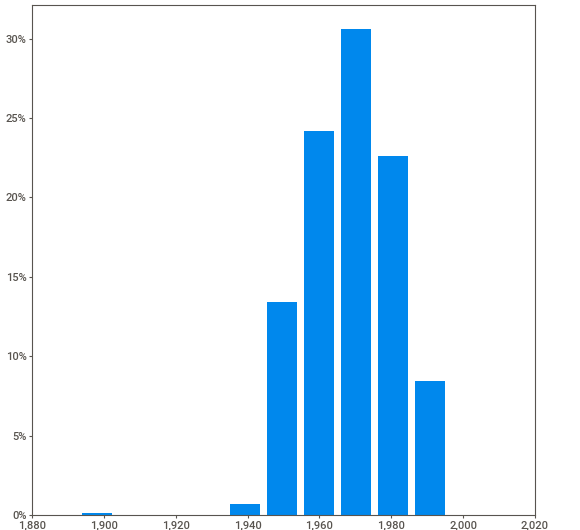
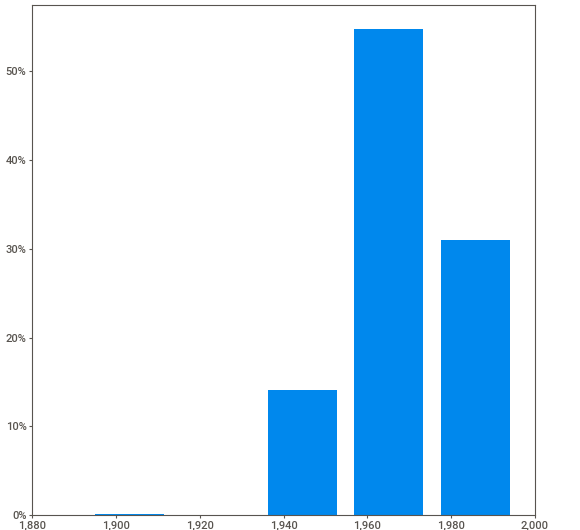
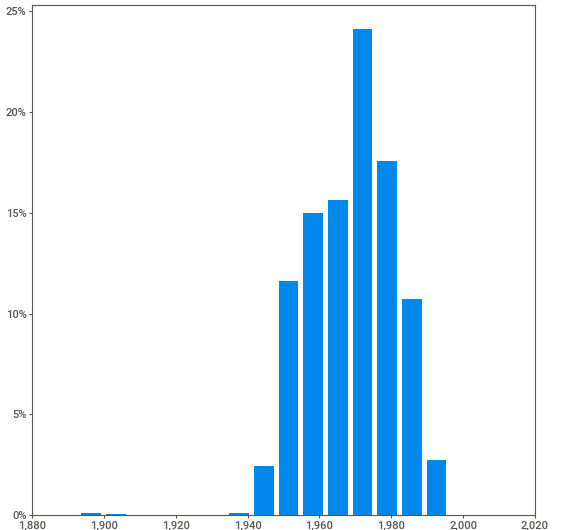
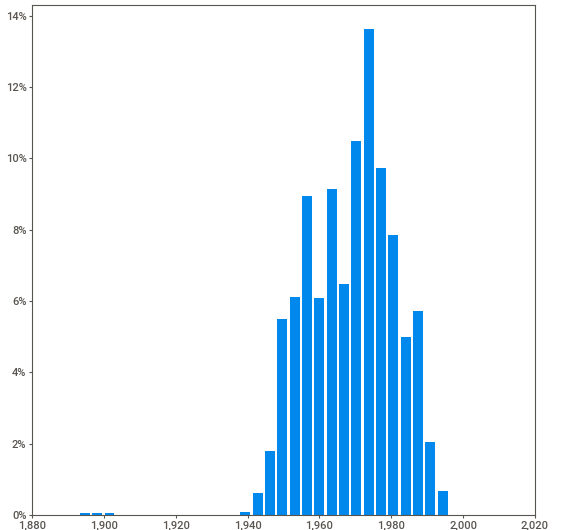
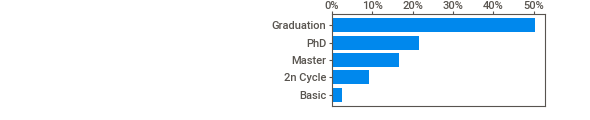
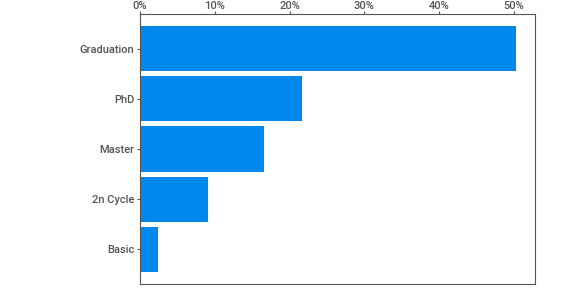
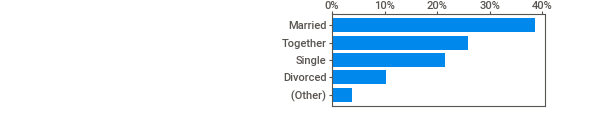
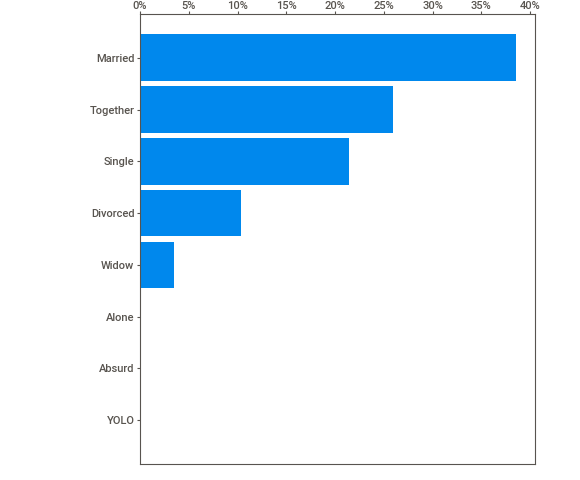
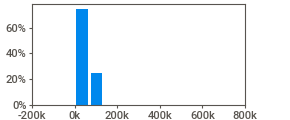
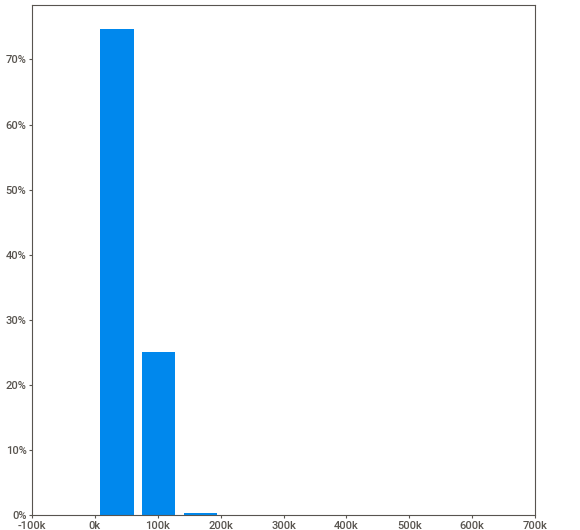
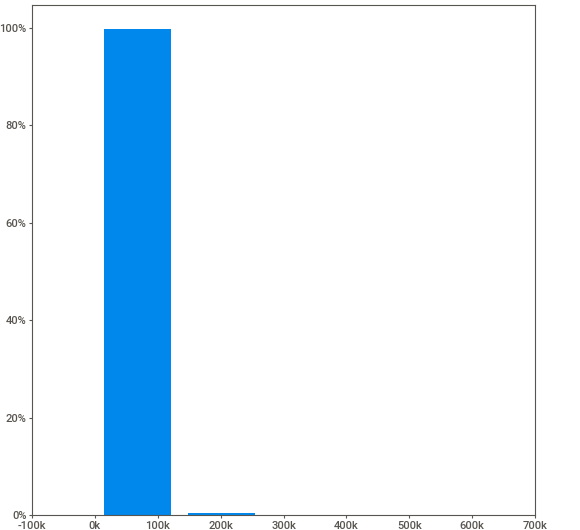
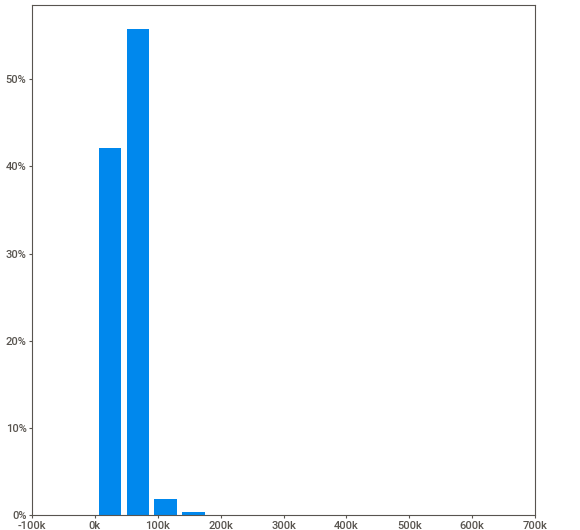
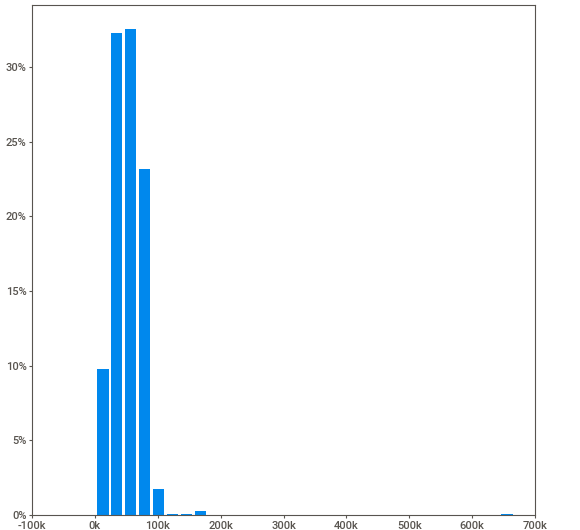
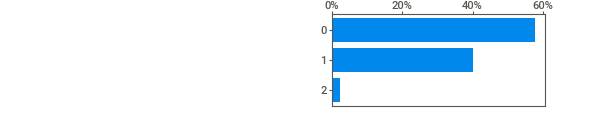
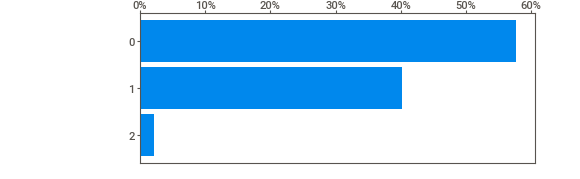
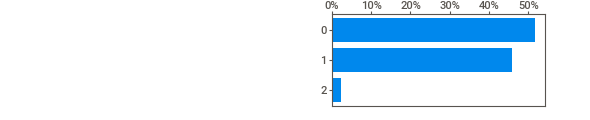
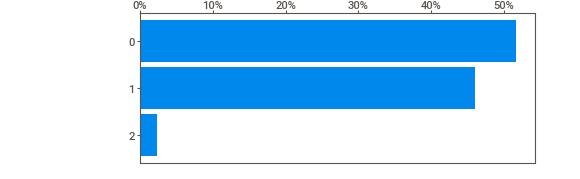
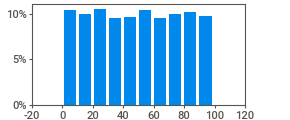
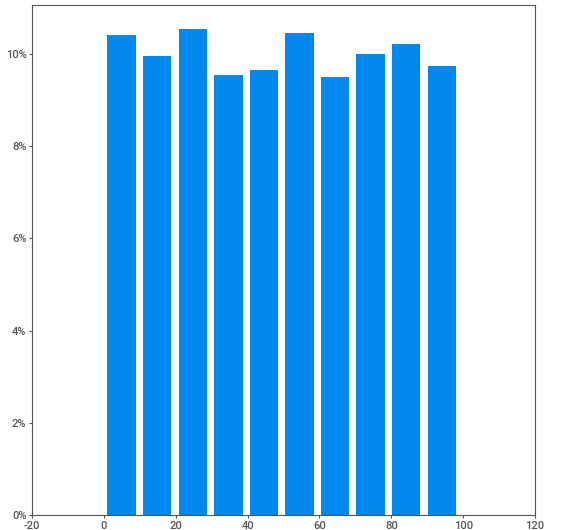
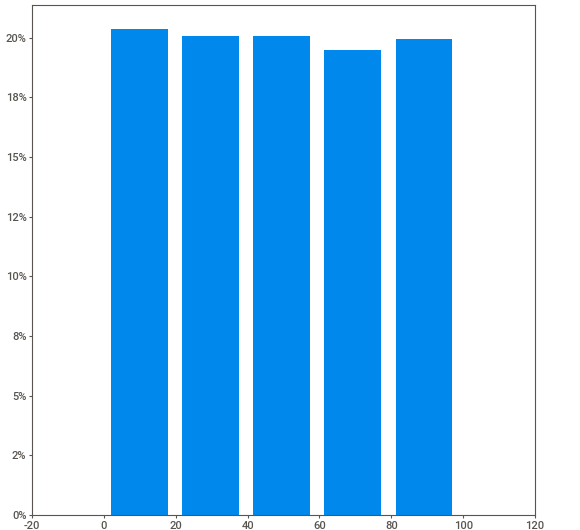
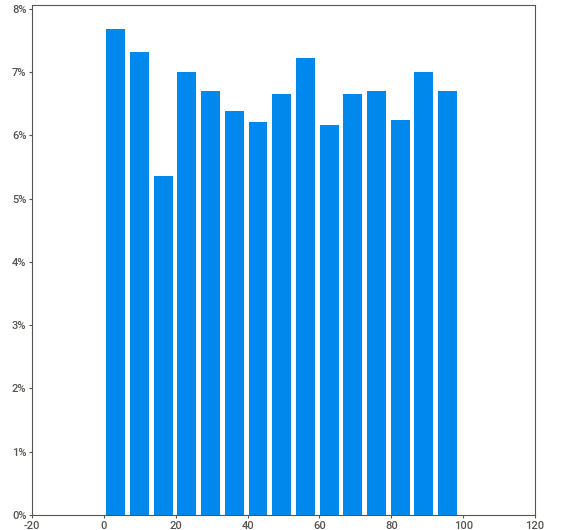
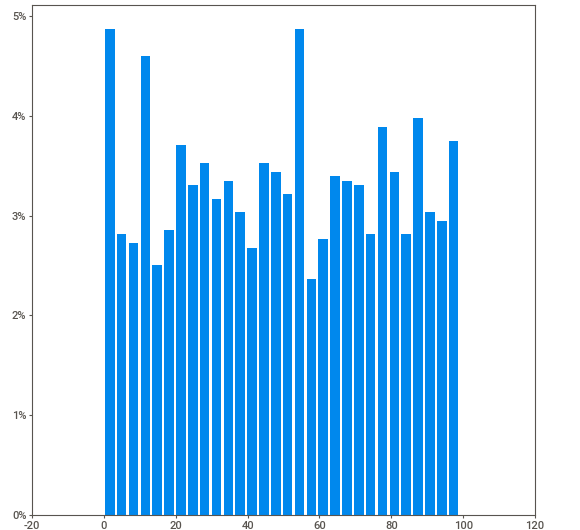
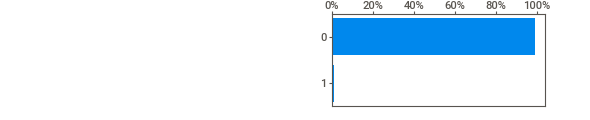
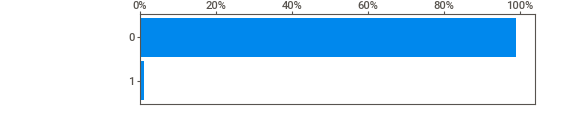
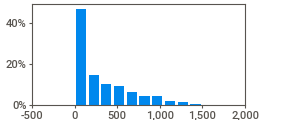
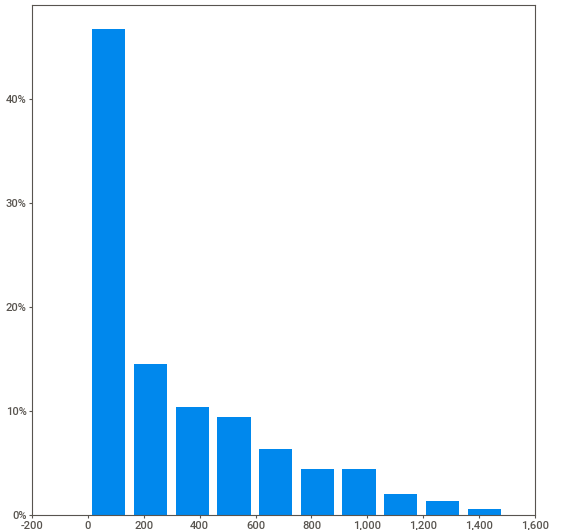
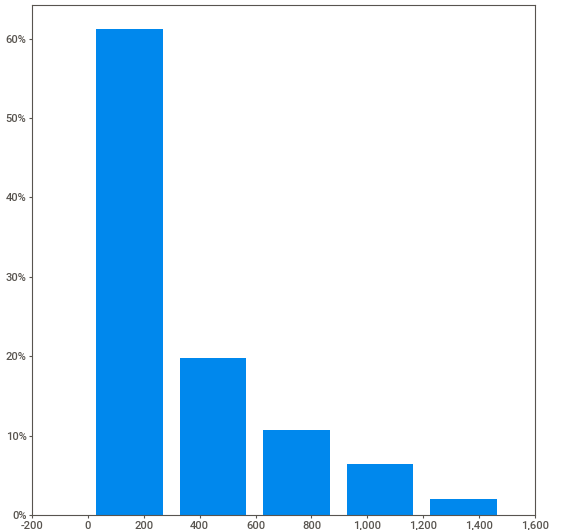
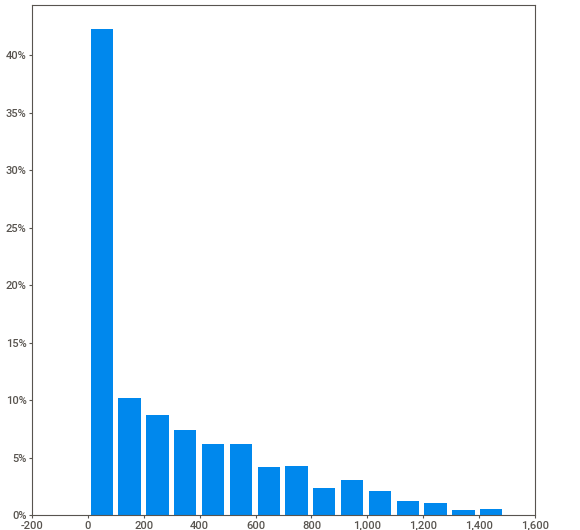
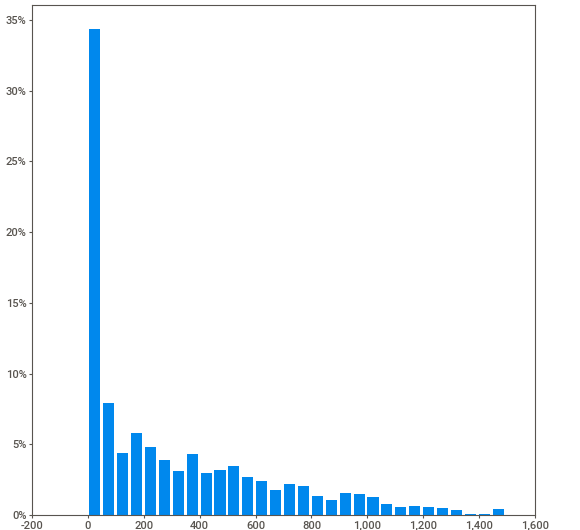
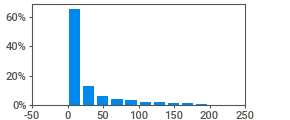
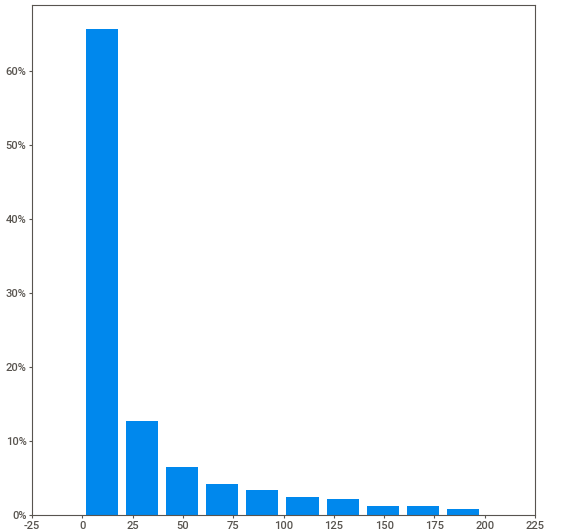
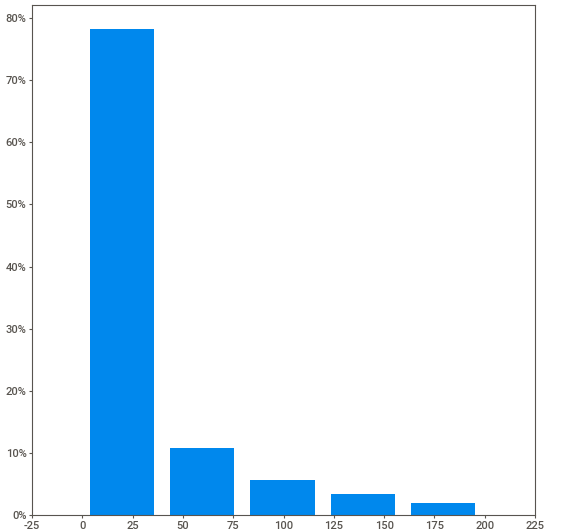
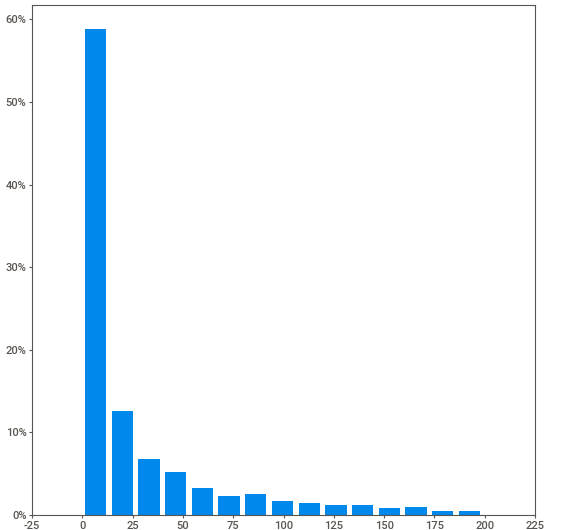
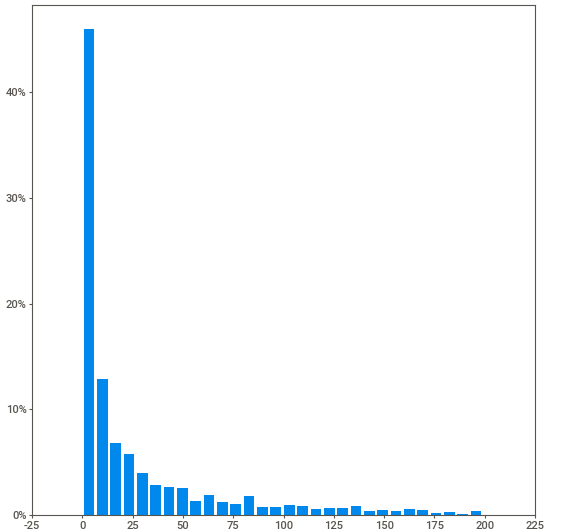
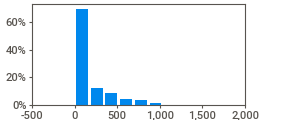
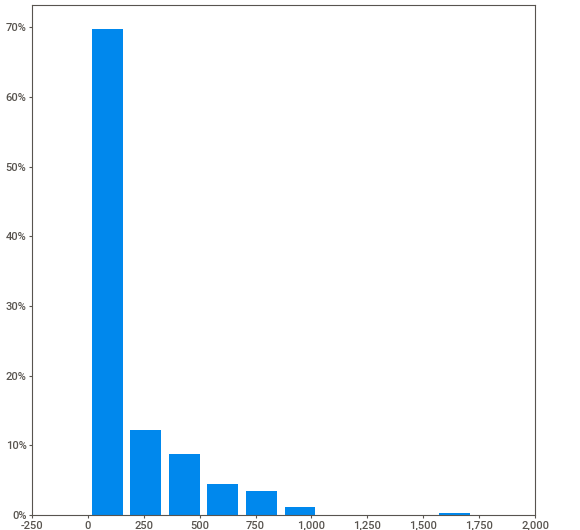
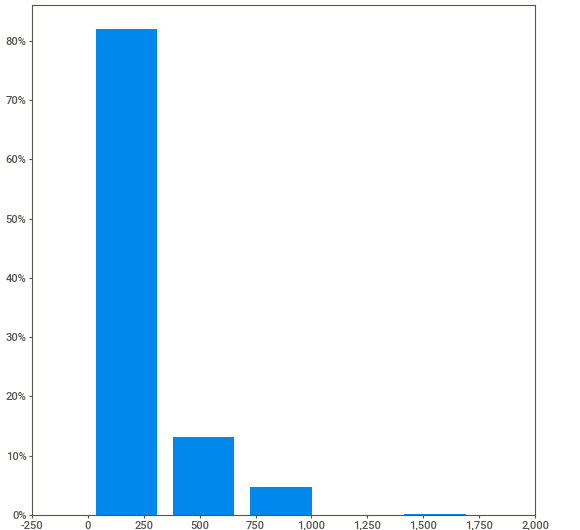
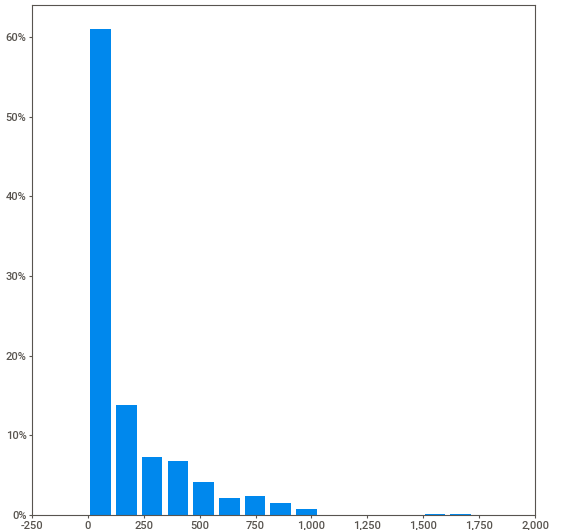
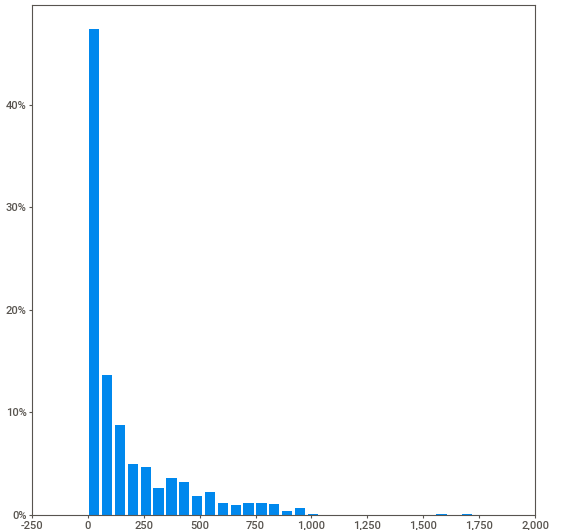
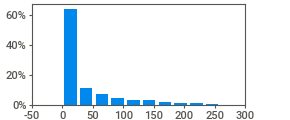
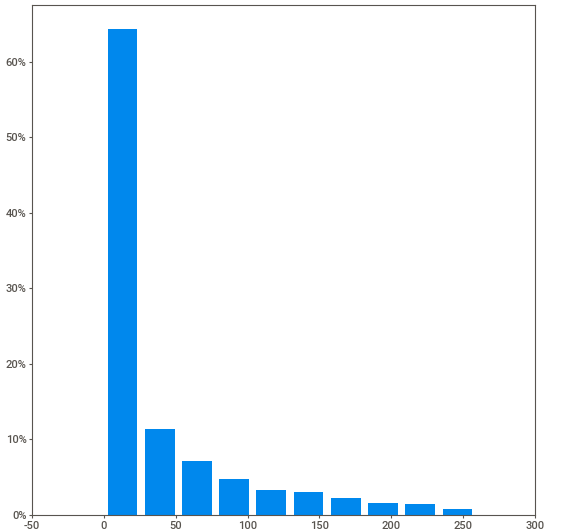
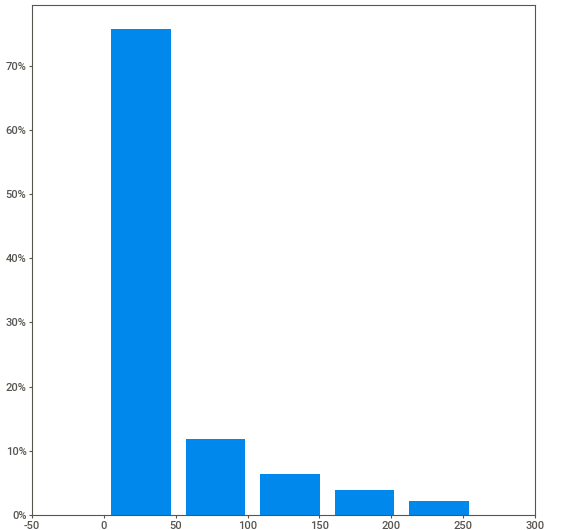
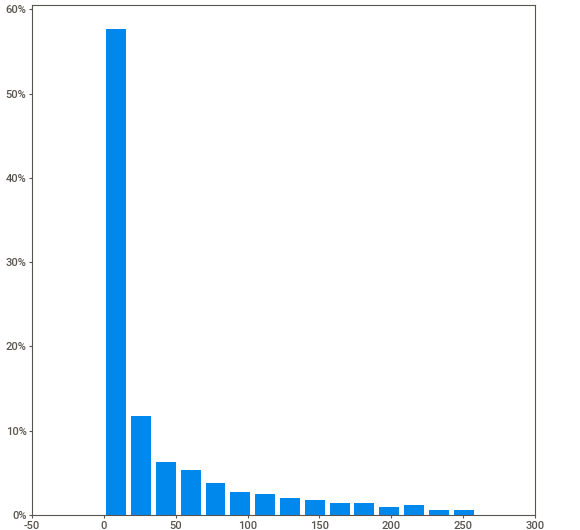
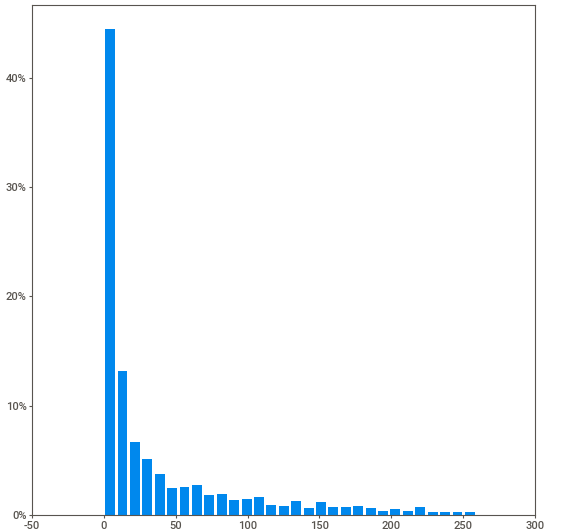
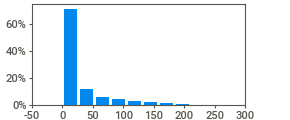
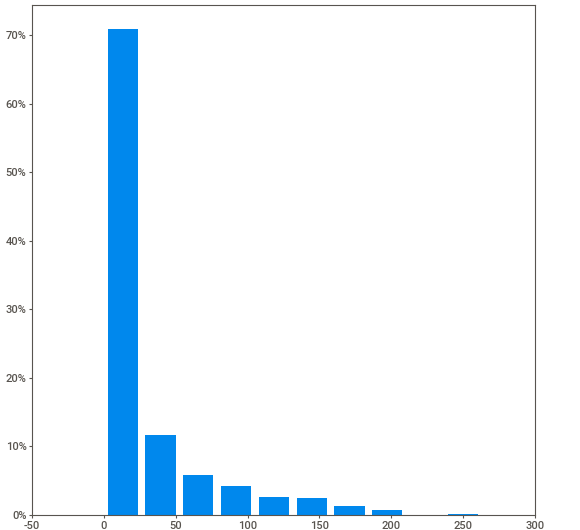
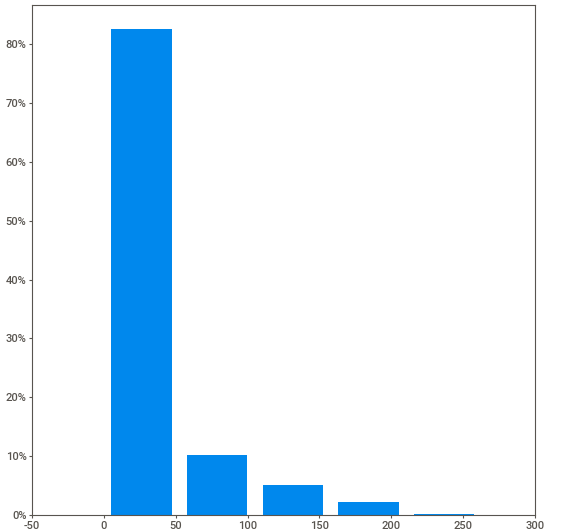
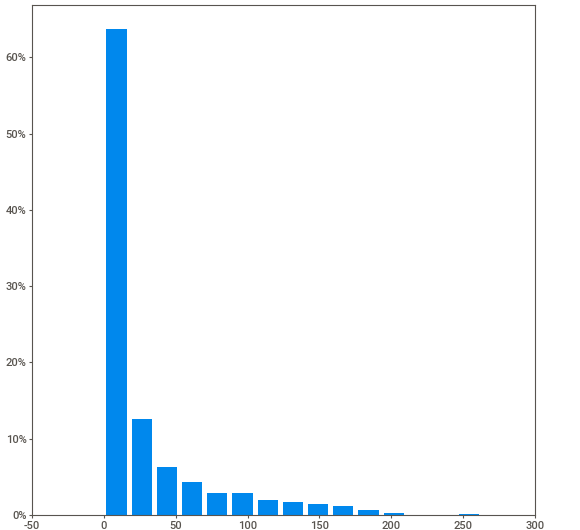
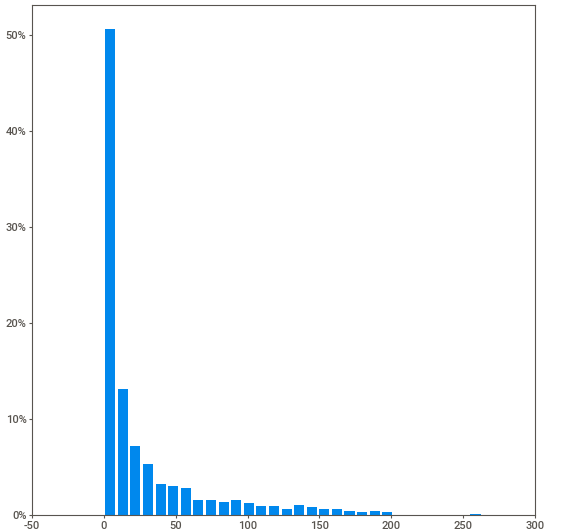
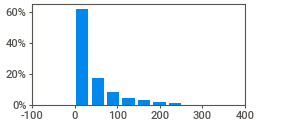
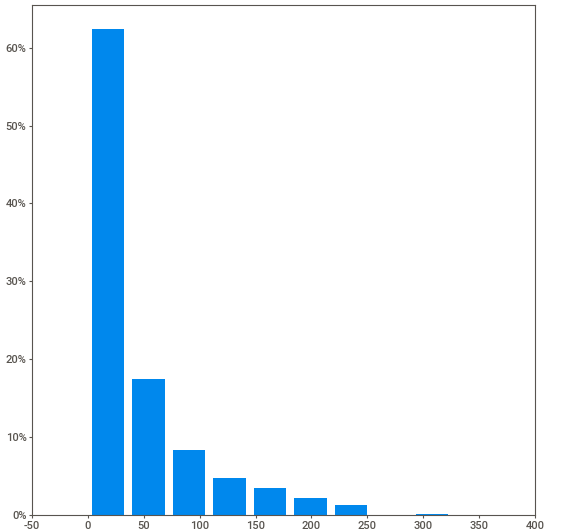
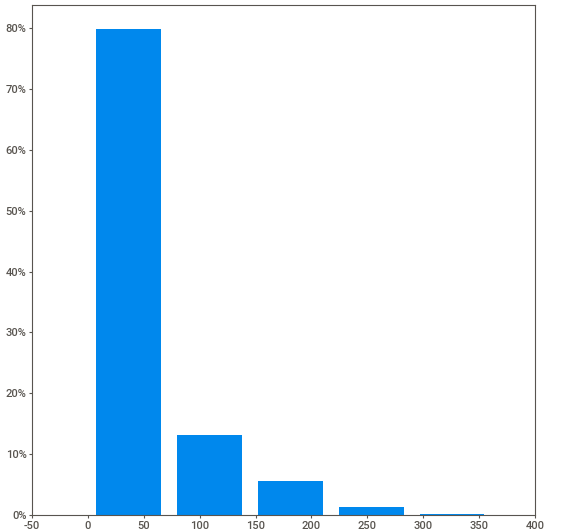
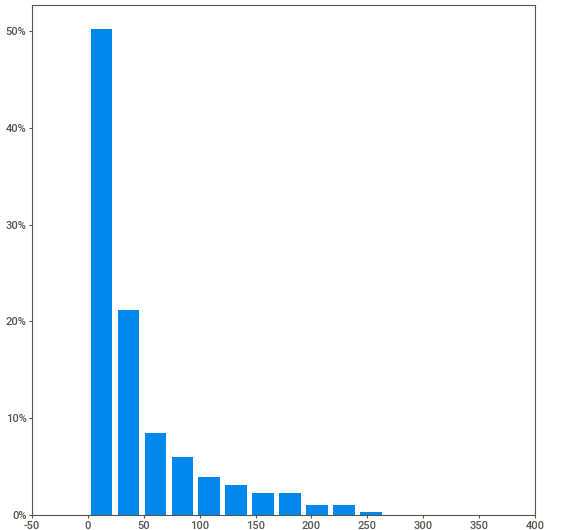
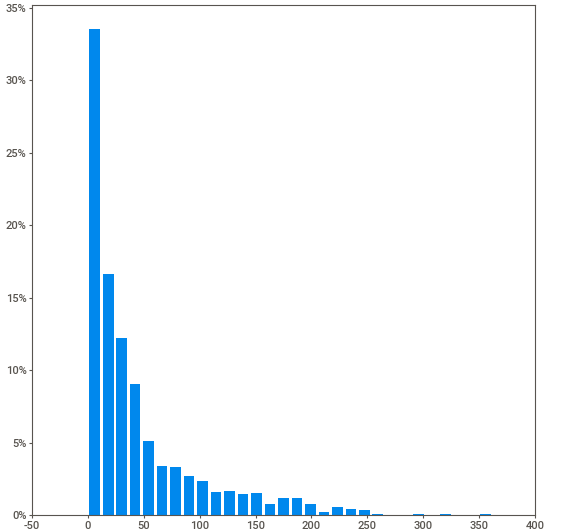
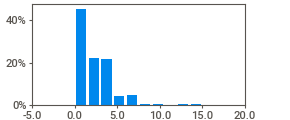
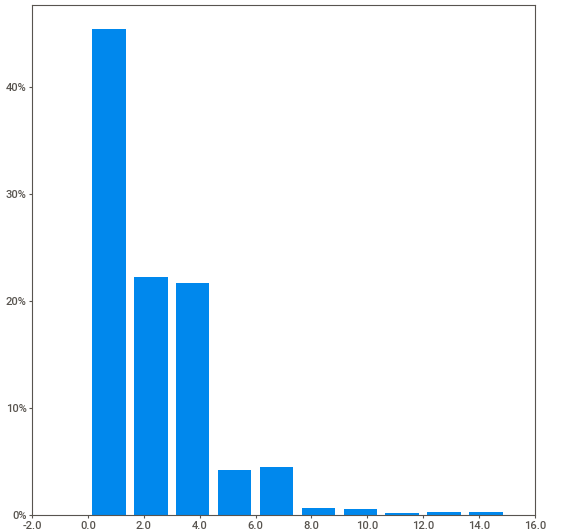
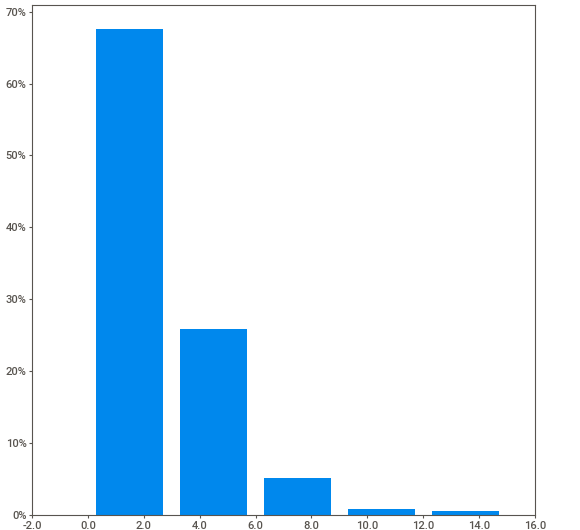
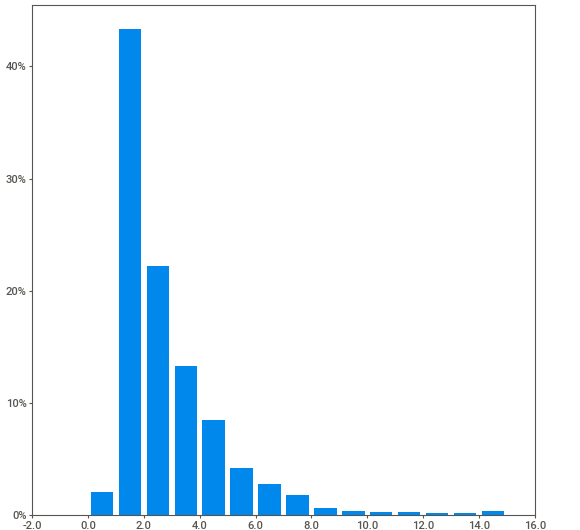
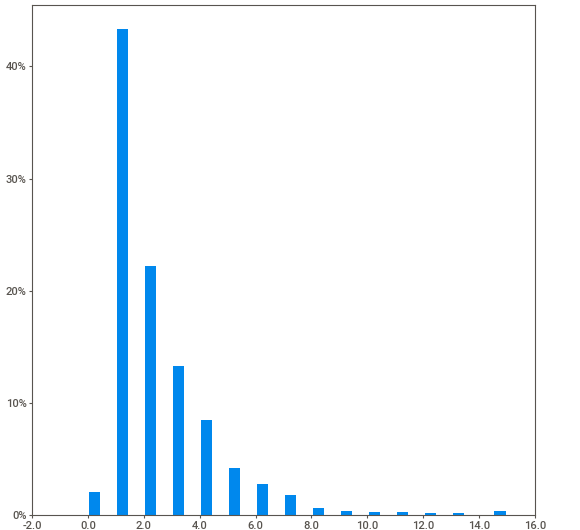
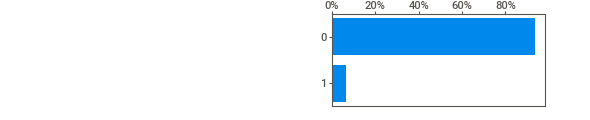
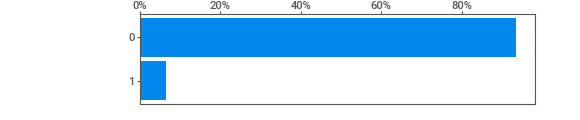
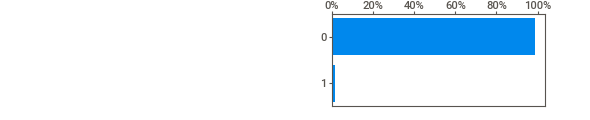
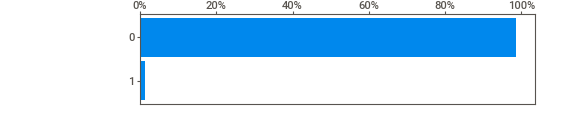
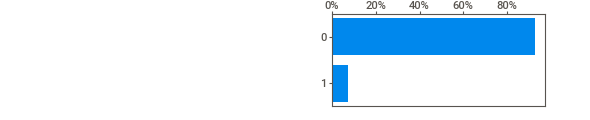
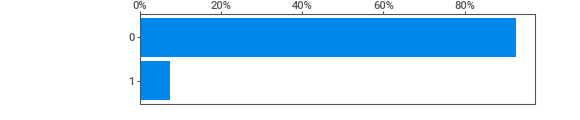
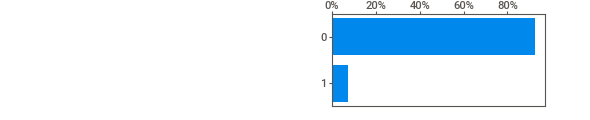
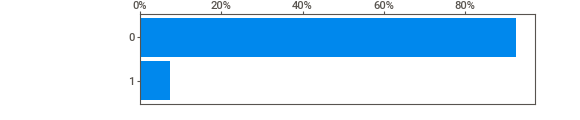
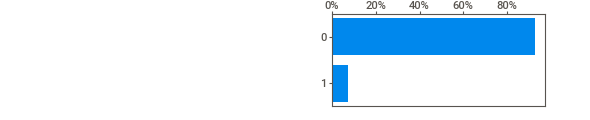
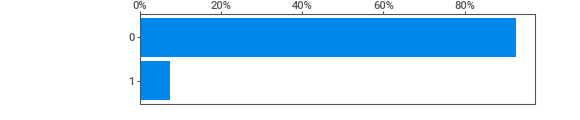
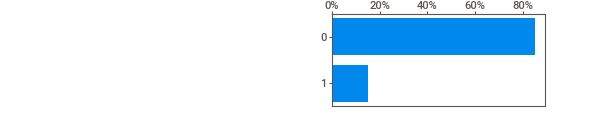
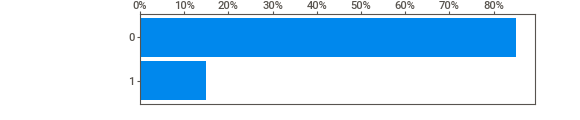
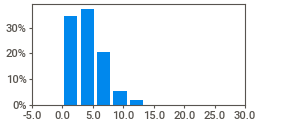
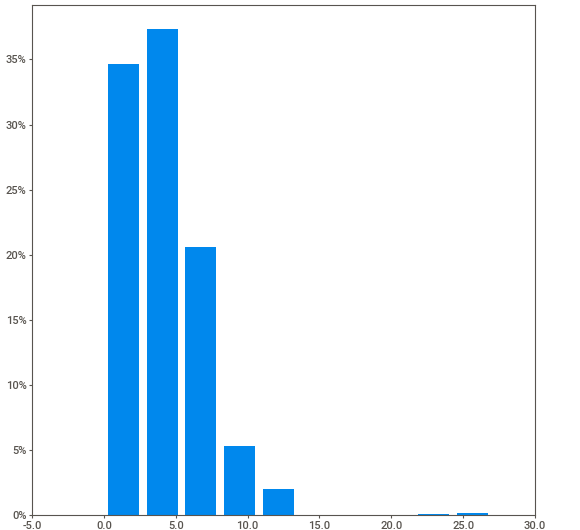
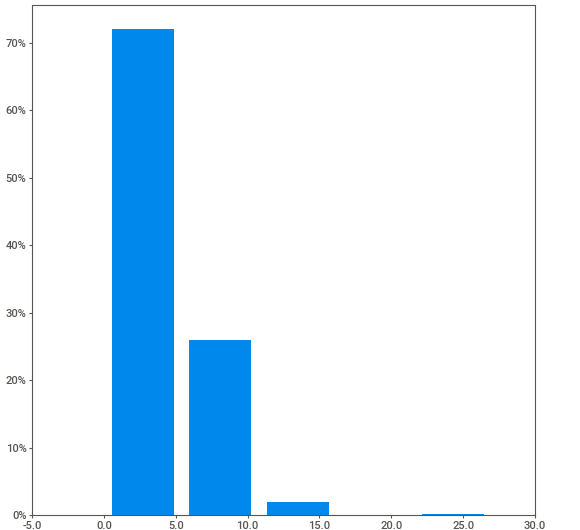
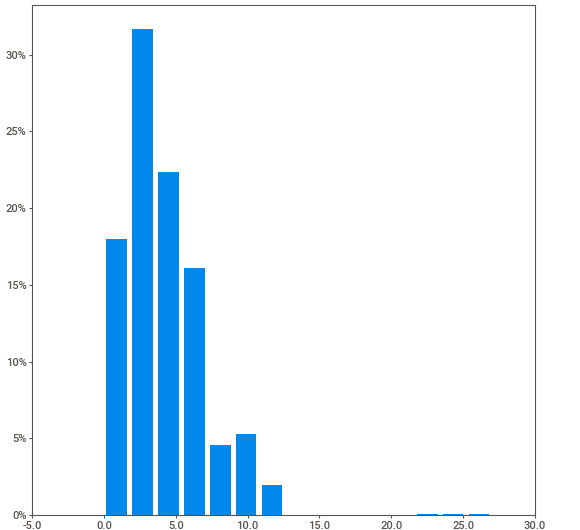
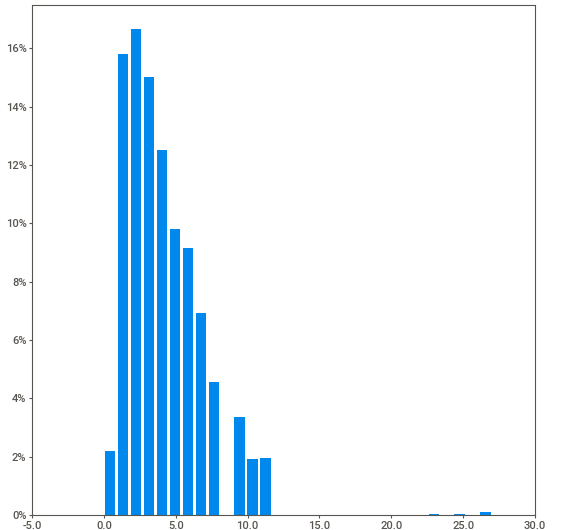
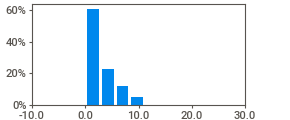
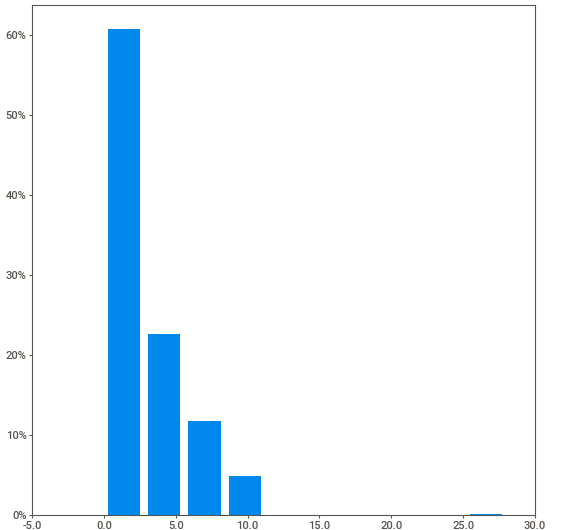
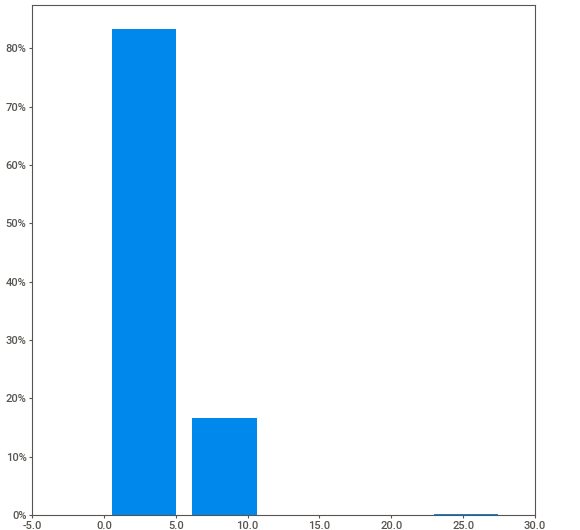
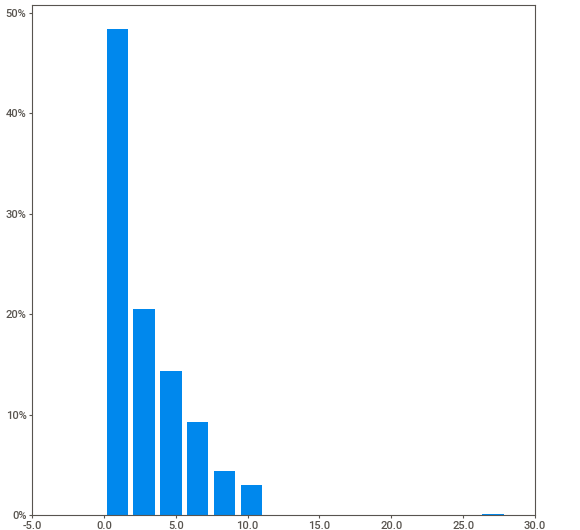
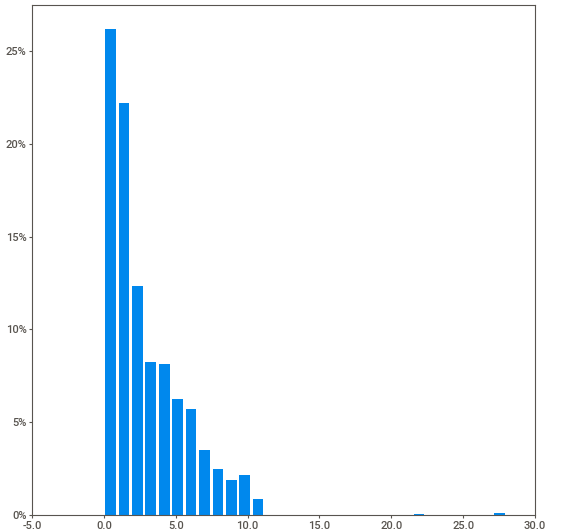
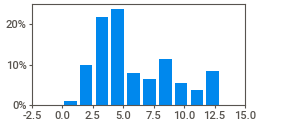
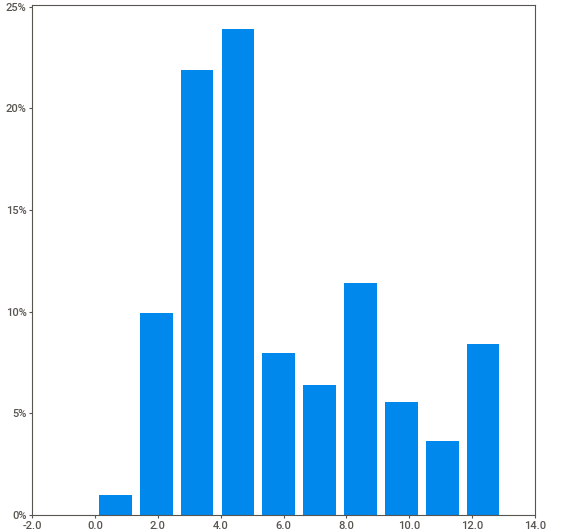
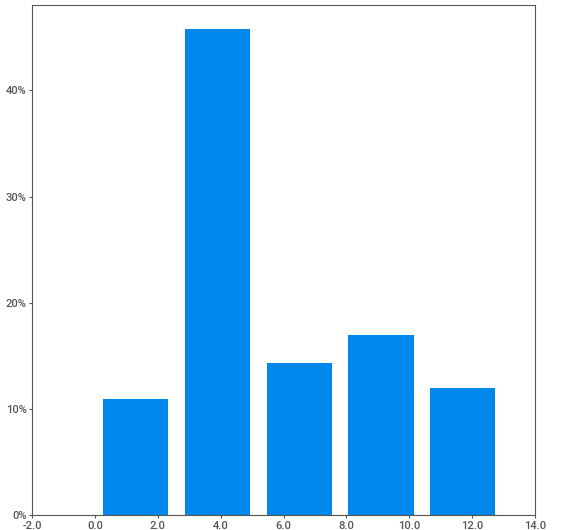
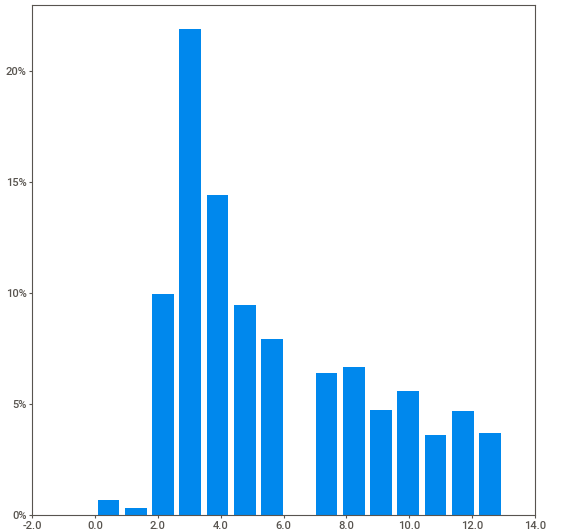
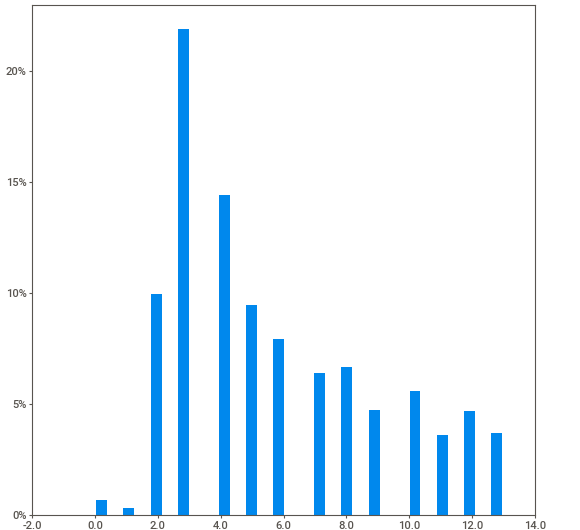
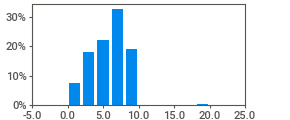
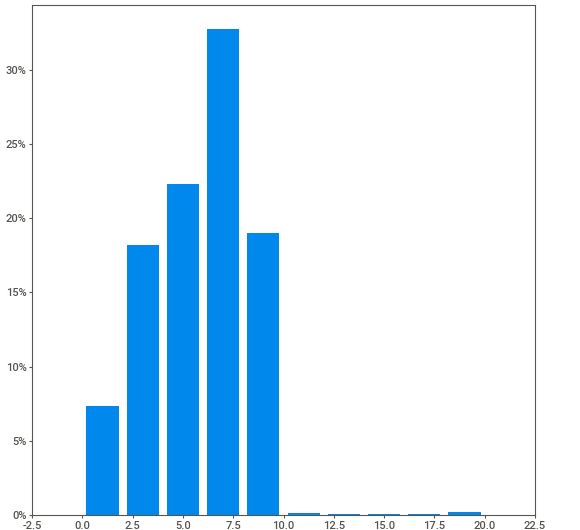
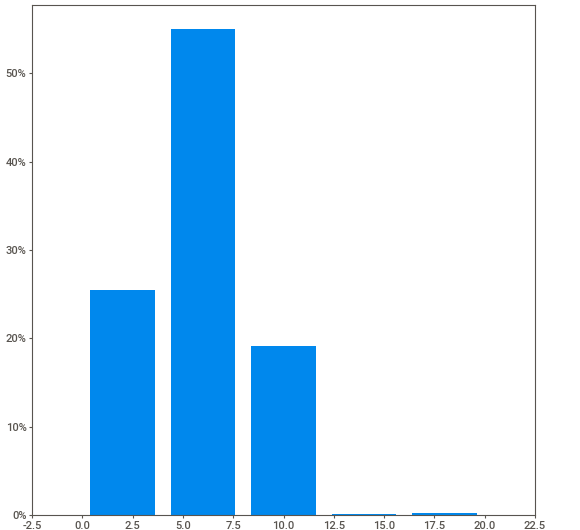
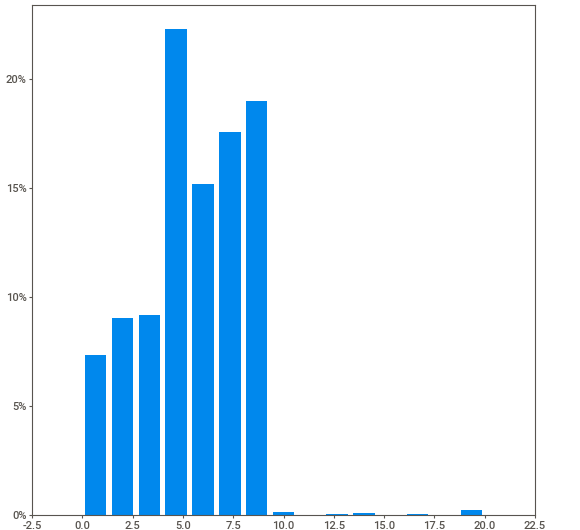
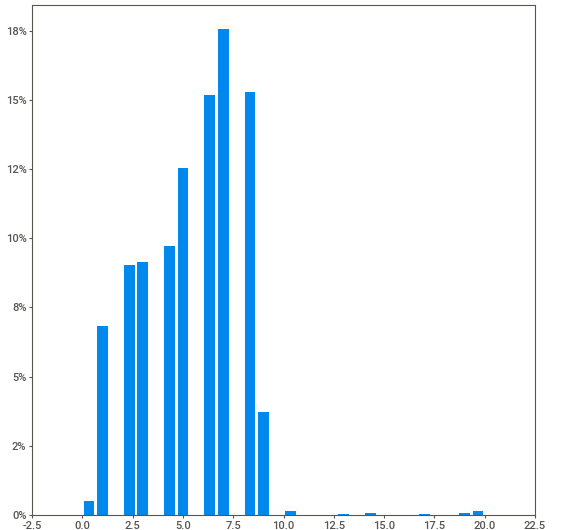
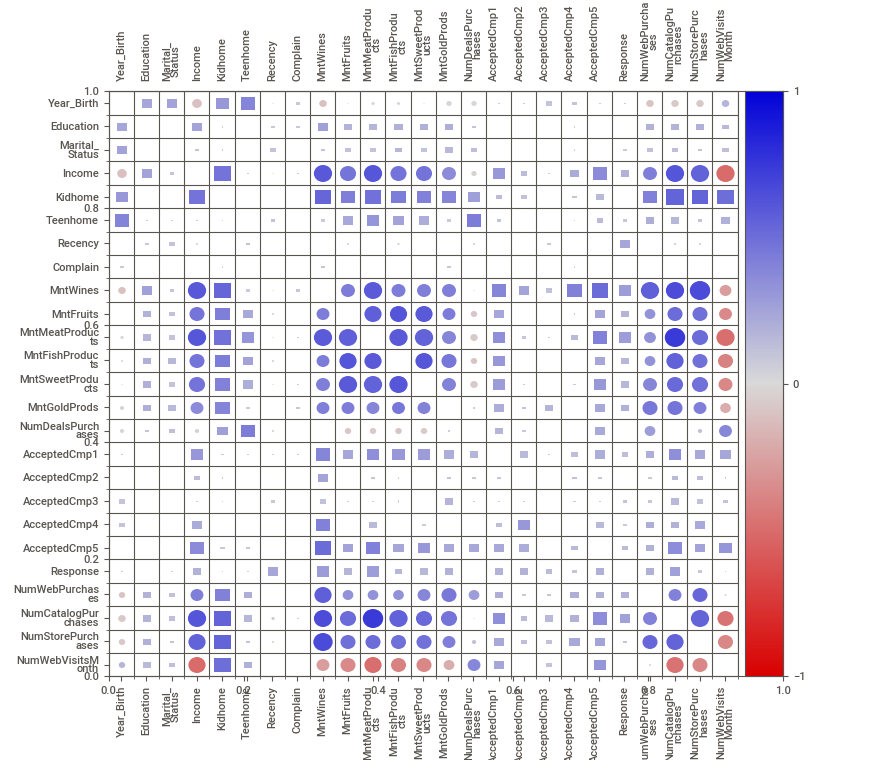
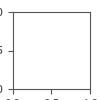

In [62]:
sweetviz_don_bien = sv.analyze(marketing_data)
report.show_html('sweetviz_don_bien.html', open_browser=False)
display(HTML('sweetviz_don_bien.html'))

## AutoViz

Shape of your Data Set loaded: (2058, 27)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  1
    Number of Integer-Categorical Columns =  15
    Number of String-Categorical Columns =  2
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  2
    Number of Numeric-Boolean Columns =  7
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    27 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
To fix these data quality issues in the dataset, import FixDQ from autoviz...
    All variab

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
Year_Birth,int64,0.000000,2,1893.000000,1996.000000,Column has 3 outliers greater than upper bound (2004.00) or lower than lower bound(1932.00). Cap them or remove them.
Education,object,0.000000,0,,,No issue
Marital_Status,object,0.000000,0,,,"3 rare categories: ['Alone', 'Absurd', 'YOLO']. Group them into a single category or drop the categories."
Income,float64,0.000000,NA,1730.000000,666666.000000,Column has 8 outliers greater than upper bound (117053.62) or lower than lower bound(-13109.38). Cap them or remove them.
Kidhome,int64,0.000000,0,0.000000,2.000000,No issue
Teenhome,int64,0.000000,0,0.000000,2.000000,No issue
Recency,int64,0.000000,4,0.000000,99.000000,No issue
Complain,int64,0.000000,0,0.000000,1.000000,No issue
MntWines,int64,0.000000,37,0.000000,1493.000000,Column has 33 outliers greater than upper bound (1225.50) or lower than lower bound(-698.50). Cap them or remove them.
MntFruits,int64,0.000000,7,0.000000,199.000000,Column has 207 outliers greater than upper bound (81.00) or lower than lower bound(-47.00). Cap them or remove them.


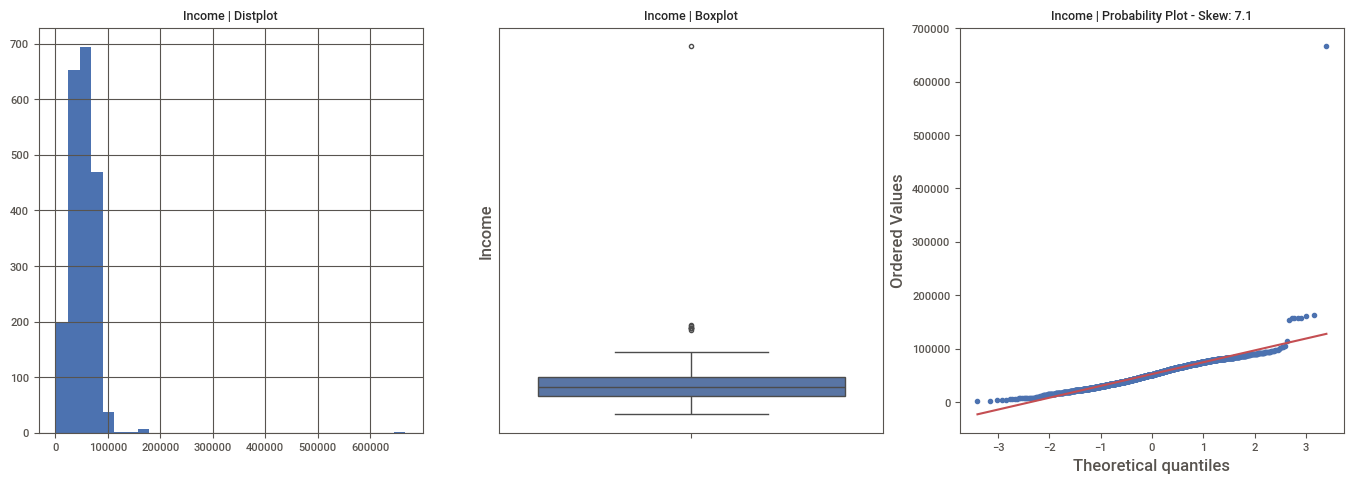

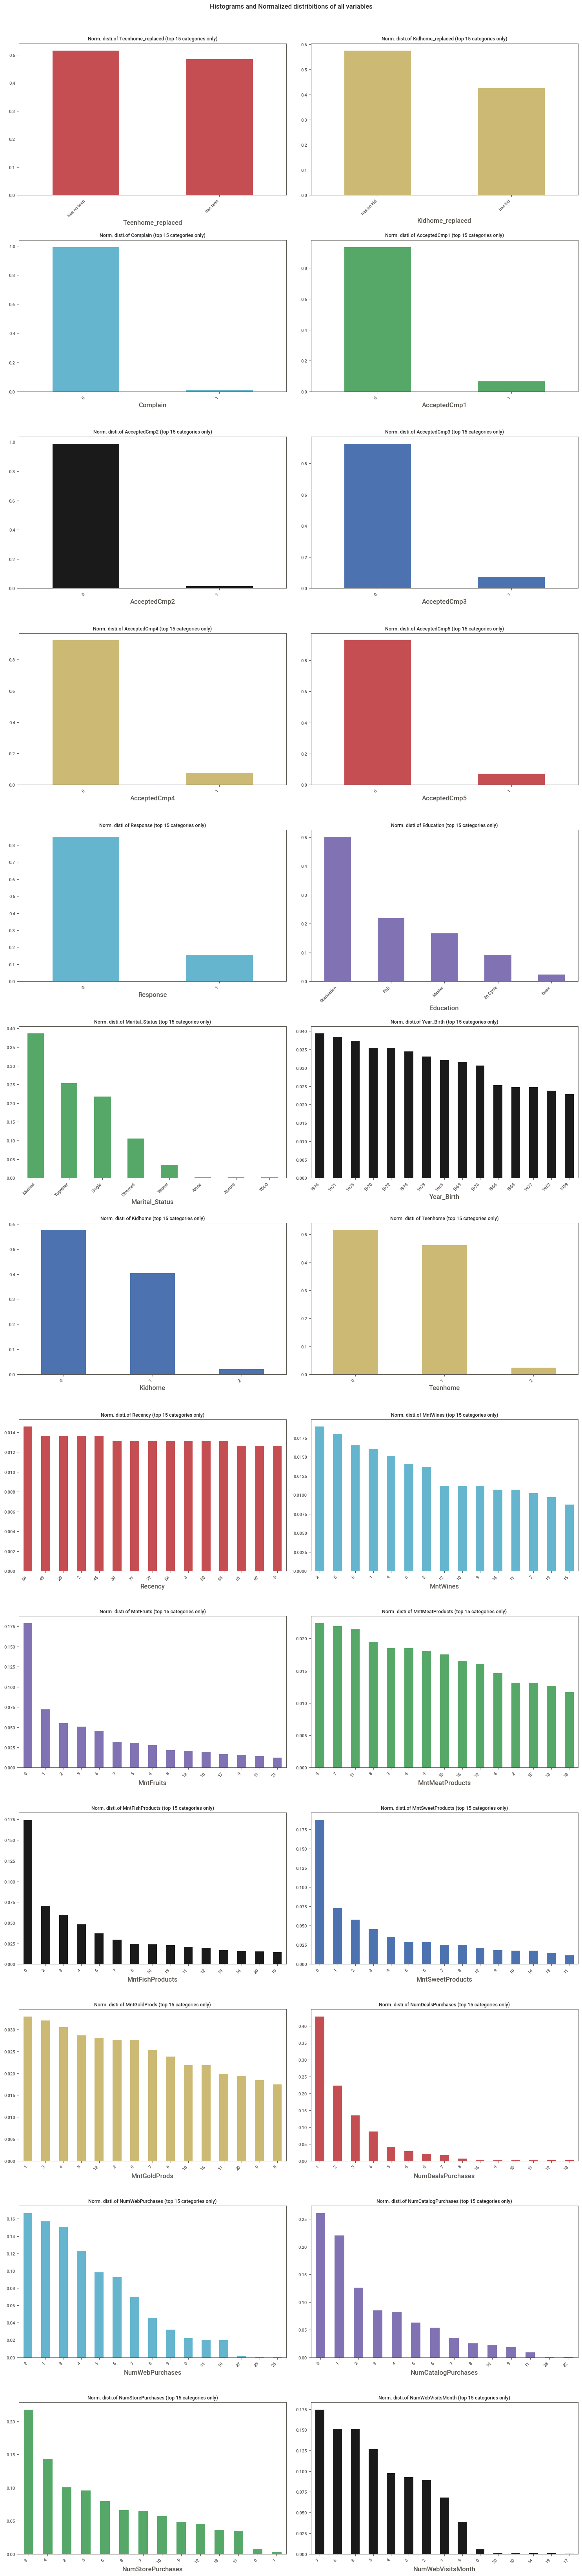

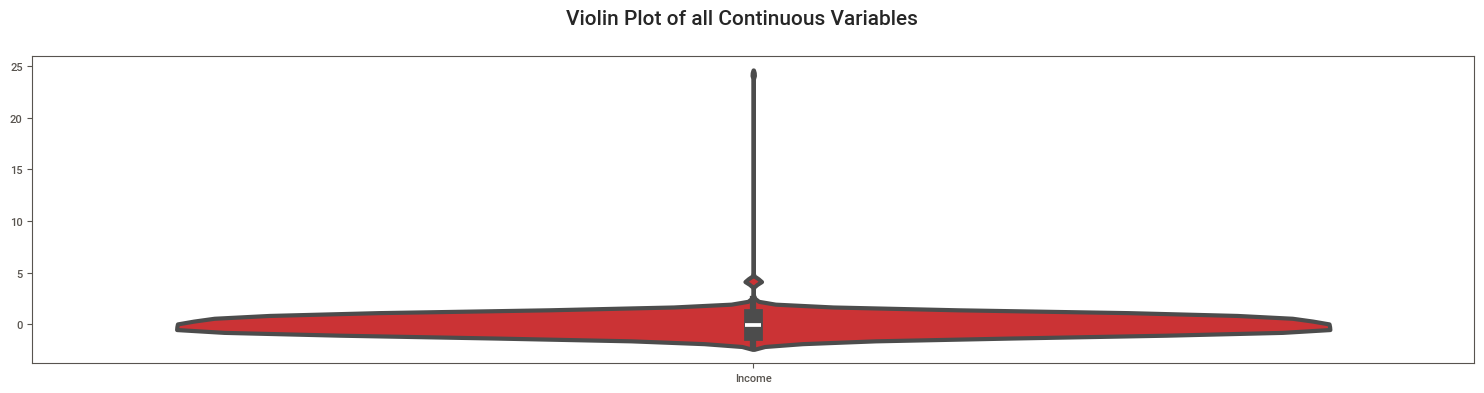

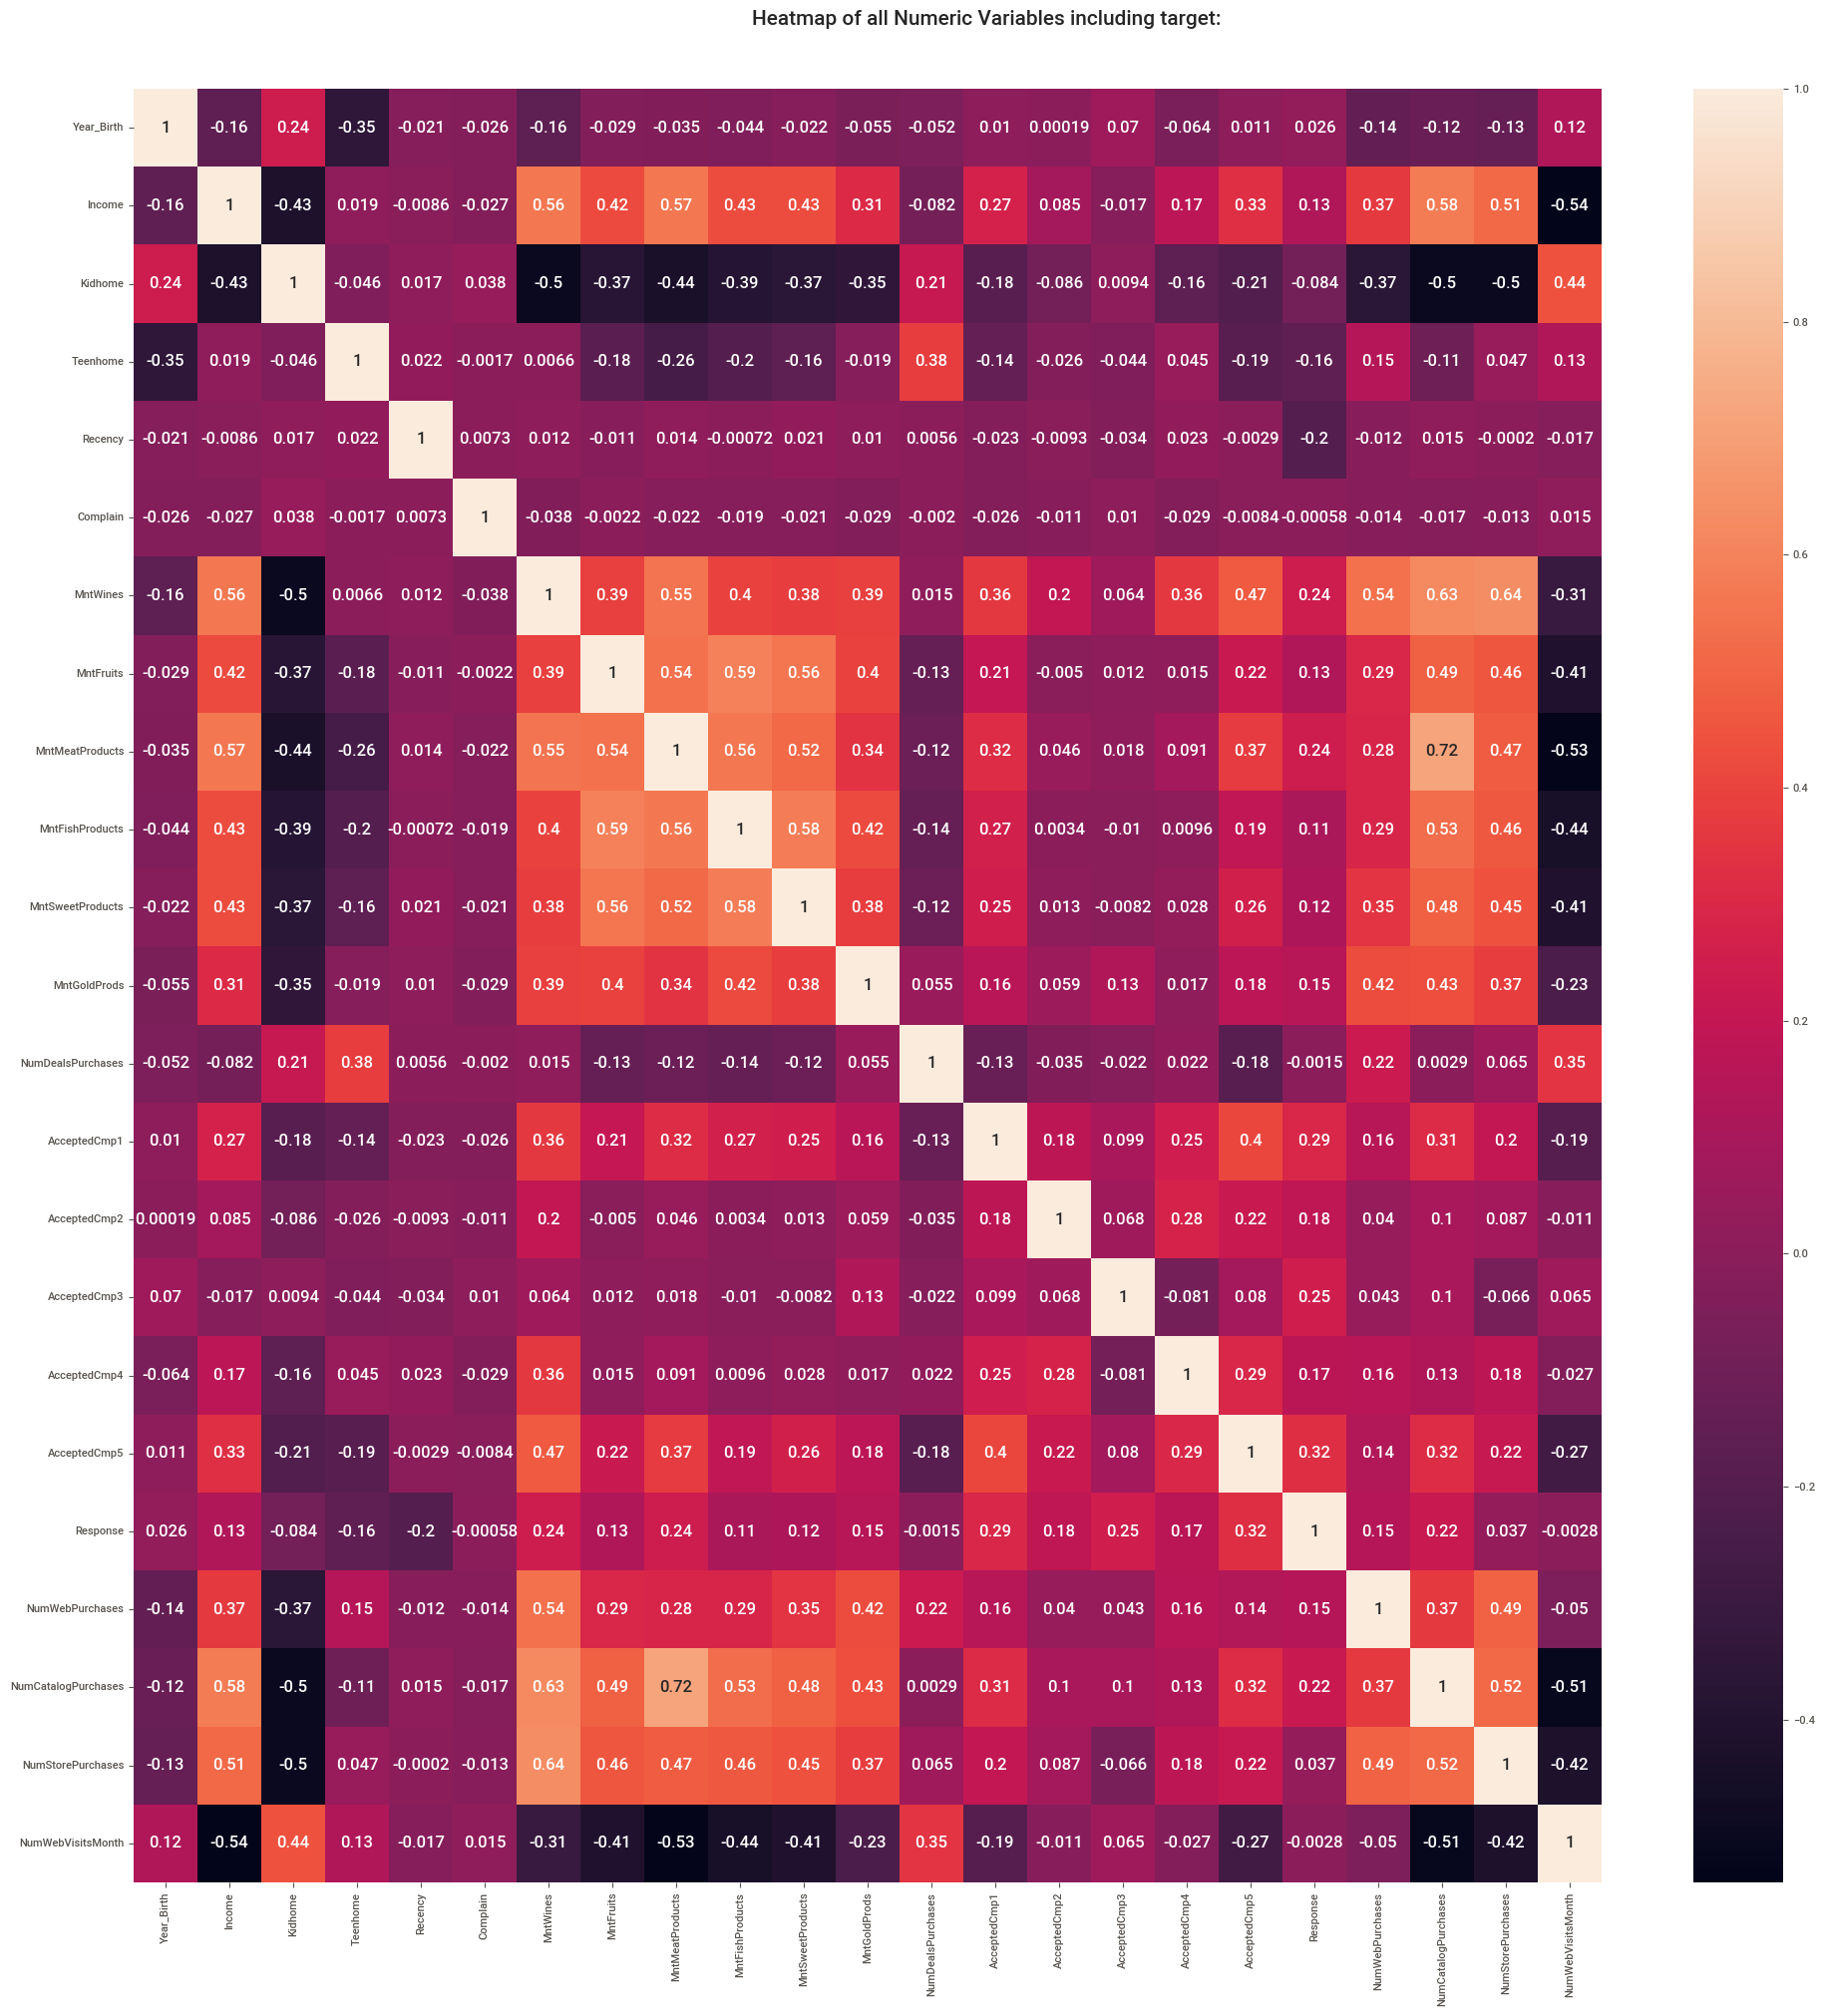

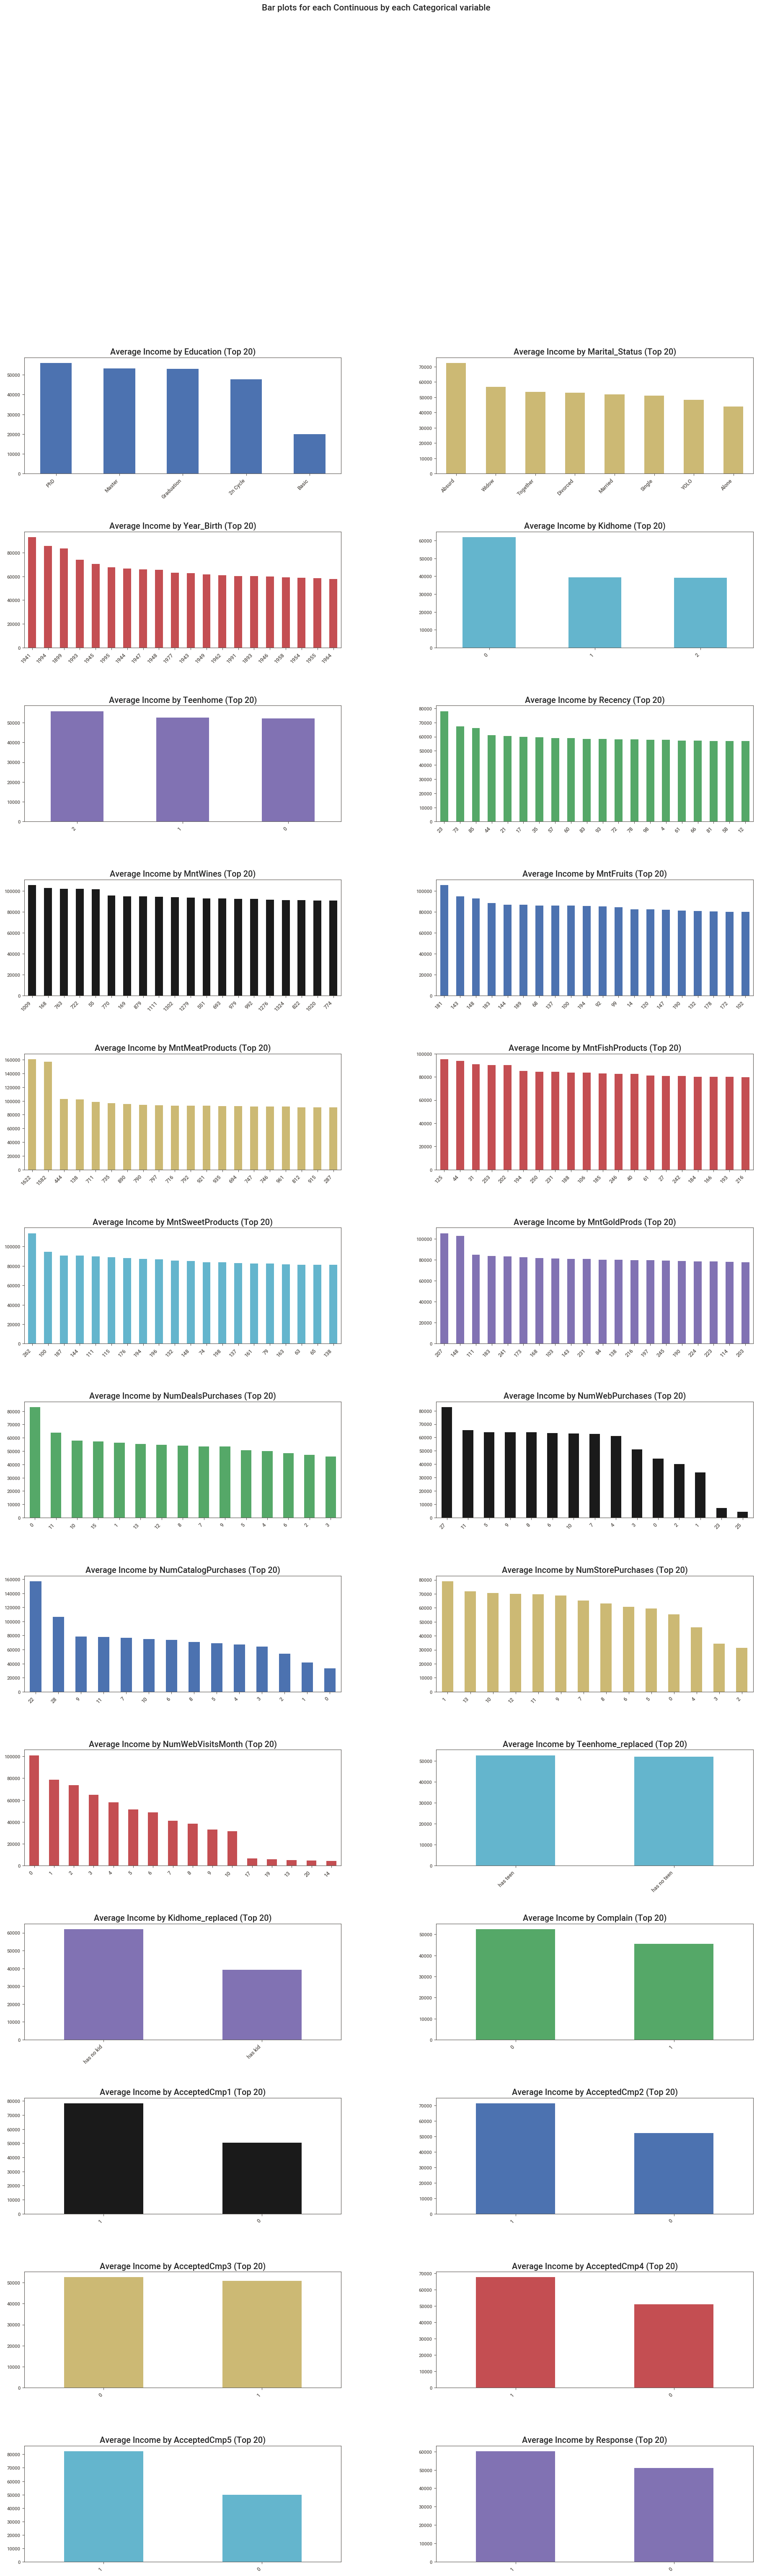

All Plots done
Time to run AutoViz = 15 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [61]:
!pip install matplotlib --upgrade
%matplotlib inline
AV = AutoViz_Class()
AV.AutoViz(    filename='',
    sep=',',
    depVar='',
    dfte=marketing_data,
    verbose=1,
    chart_format='png'
)
plt.close('all')

# Kết thúc